<a href="https://colab.research.google.com/github/Trickwillfrit/Sustainable-logistics/blob/main/notebooks/02_Optimization_Hospital_Facility_Location_Vaud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 02 — Optimization models
## Hospital Facility Location — Canton of Vaud

**Master in Sustainability Management and Technologies — Logistics project**

## 1. Introduction

This notebook builds and solves all the optimization models for the final report. The data cleaning, EDA and baseline statistics have been done in the first notebook (`01_EDA_Hospital_Facility_Location_Vaud.ipynb`), which exports six clean CSV files we reload here.

### Models in this notebook

| # | Model | Objective | Capacity? | Distance constraint |
|---|---|---|---|---|
| 0 | Current system (reference) | — | — | — |
| 1 | Uncapacitated cost | $\min \sum_j C_j y_j$ | no | $D = 16$ km |
| 2 | Uncapacitated cost — scenario sweep | same | no | $D \in \{8,...,25\}$ |
| 3 | Capacitated cost | $\min \sum_j C_j y_j$ | yes | $D$ |
| 4 | Capacitated cost — scenario sweep | same | yes | $D \in \{8,...,25\}$ |
| 5 | Emissions minimization | $\min \sum_j E_j y_j + e_{km}\sum_{ij} q_i \, d_{ij} x_{ij}$ | yes | $D$ |
| 6 | Demand-growth sensitivity | model 3 with various demand multipliers | yes | $D$ |

**Important: every cost model minimizes cost, NOT the number of hospitals.** The hospital count is reported as a KPI only.

### Optimization granularity

All models work at the **commune × hospital** level (300 communes × 50 hospitals). Districts are used only for reporting and interpretation — never as decision units.

### Mathematical formulation (reference)

**Sets** — $I$ = communes (300), $J$ = hospitals (50).

**Parameters**
- $d_{ij}$ — distance commune $i$ → hospital $j$ (km)
- $P_i$ — population of commune $i$ (year 2024 by default; multiplied by a growth factor in model 6)
- $q_i = P_i \cdot 0.164 \cdot 5 / 365$ — bed demand of commune $i$ (simultaneous occupancy)
- $C_j$ — running cost of hospital $j$ (CHF / year)
- $B_j$ = `Beds_Total` — per-facility bed capacity from `costs_hospitals_full.csv`
- $E_j$ — allocated operational emissions of hospital $j$ (t CO₂ / year)
- $e_{km}$ — transport emission factor (kg CO₂ / passenger-km)
- $D$ — maximum allowed distance threshold (km)

**Decision variables**
- $y_j \in \{0, 1\}$ — 1 if hospital $j$ is open
- $x_{ij} \in [0, 1]$ — fraction of commune $i$'s demand served by hospital $j$ (continuous; demand can be split across hospitals when needed)

> Why continuous $x_{ij}$? In real life patients don't all go to the same hospital, so a split assignment is more realistic. Continuous $x_{ij}$ also keeps the MILP much smaller (only the 50 $y_j$ are integer), so it solves in seconds in Colab. For reporting, each commune is attached to its "primary" hospital — the one with the largest $x_{ij}$.

### A note on feasibility (transparent finding)

The structure of the data implies that the **capacitated** model is **infeasible for $D \le 18$ km**. The reason is the **Payerne area**: several communes can only reach the Hôpital de Payerne within 16 – 18 km, but Payerne has only 47 beds, which cannot absorb the local forced demand. We document this in the scenario sweep instead of hiding it — it is itself an important finding for the final report. The capacitated model becomes feasible at $D = 20$ km.

The **uncapacitated** model is feasible at $D = 16$ km (and also for any $D \ge 16$).


## 2. Load libraries

In [ ]:
!pip install ortools -q


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.8/29.8 MB 35.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 135.8/135.8 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 kB 22.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-ai-generativelanguage 0.6.15 requires protobuf!=4.21.0,!=4.21.1,!=4.21.2,!=4.21.3,!=4.21.4,!=4.21.5,<6.0.0dev,>=3.20.2, but you have protobuf 6.33.6 which is incompatible.
grpcio-status 1.71.2 requires protobuf<6.0dev,>=5.26.1, but you have protobuf 6.33.6 which is incompatible.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from ortools.linear_solver import pywraplp

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')


## 3. Key parameters

All assumptions are gathered in one place — change them here to test sensitivity.


In [ ]:
# --- Demand assumption ---
HOSPITALIZATION_RATE = 0.164   # share of population requiring a stay per year
AVG_LENGTH_OF_STAY   = 5       # days
DAYS_PER_YEAR        = 365

# --- Transport emission factor ---
EMISSION_FACTOR_KM   = 0.12    # kg CO2 / passenger-km

# --- Default distance threshold ---
D_DEFAULT_KM         = 16

# --- Hospitalization forecasting parameters ---
BASE_YEAR                   = 2022
BASE_HOSPITALIZATION_RATE   = 0.164
HOSPITALIZATION_GROWTH_RATE = 0.0333   # 3.33% per year

# --- GitHub raw URL (fallback if clean files are not on disk) ---
BASE_URL = "https://raw.githubusercontent.com/Trickwillfrit/Sustainable-logistics/main/"

# --- Forecasting functions ---
def forecast_hospitalization_rate(target_year,
                                  base_year=BASE_YEAR,
                                  base_rate=BASE_HOSPITALIZATION_RATE,
                                  annual_growth=HOSPITALIZATION_GROWTH_RATE):
    return base_rate * (1 + annual_growth) ** (target_year - base_year)

def get_demand_for_year(target_year, population):
    """Compute demand arrays for a given target year.
    Returns: demand_beds, patients_annual, hospitalization_rate
    """
    rate = forecast_hospitalization_rate(target_year)
    annual_hosp = population * rate
    patients_annual = annual_hosp / DAYS_PER_YEAR * AVG_LENGTH_OF_STAY
    demand_beds = patients_annual
    return demand_beds, patients_annual, rate


## 4. Load the clean data

We first try to load the six CSVs exported by the EDA notebook. If they are missing (e.g. we are in a fresh Colab session), we re-run a minimal version of the cleaning from the raw GitHub files.


In [ ]:
def load_clean_data():
    """Load the clean files from disk, or rebuild from raw if they are missing."""
    files = ["clean_hospitals.csv","clean_communes.csv","clean_distance_matrix.csv",
             "clean_costs.csv","clean_emissions.csv"]
    if all(os.path.exists(f) for f in files):
        print("Loading clean files from disk (exported by the EDA notebook)...")
        hospitals = pd.read_csv("clean_hospitals.csv")
        communes  = pd.read_csv("clean_communes.csv")
        distance  = pd.read_csv("clean_distance_matrix.csv")
        return hospitals, communes, distance
    print("Clean files not found - rebuilding from raw GitHub data...")
    return _rebuild_from_raw()


def _rebuild_from_raw():
    """Minimal rebuild of the EDA cleaning (used only as a fallback)."""
    NAME_FIXES = {
        "Hôptial d'Aubonne": "Hôpital d'Aubonne",
        "Pôle santé du Pays-d_x0019_ Enhaut": "Pôle Santé Pays-d'Enhaut",
    }
    YEAR_COLS = {f"Population au 31.12.{'' if i==0 else '.'+str(i)}": f"Pop_{2016+i}" for i in range(9)}

    dist_raw  = pd.read_csv(BASE_URL+"Distance_matrix.csv", encoding="latin1")
    hosp_raw  = pd.read_csv(BASE_URL+"hospitals_full.csv",   encoding="latin1")
    costs_raw = pd.read_csv(BASE_URL+"costs_hospitals_full.csv", sep=";", encoding="utf-8")
    emis_raw  = pd.read_csv(BASE_URL+"Hospital_emissions.csv", encoding="utf-8")
    pop_raw   = pd.read_excel(BASE_URL+"Pop_district.xlsx", sheet_name="Total")

    # Hospitals
    h = hosp_raw[hosp_raw["Canton__Facility_"]=="VD"][
        ["Facility","Town__Facility_","Institution","longitude","latitude"]].reset_index(drop=True)

    # Costs
    c = costs_raw[costs_raw["Canton__Facility_"]=="VD"][
        ["Facility","Size_Category","Beds_Total","Cost_per_Bed"]].copy()
    c["Facility"] = c["Facility"].replace(NAME_FIXES)
    c["Hospital_Cost"] = (365 * c["Cost_per_Bed"]).astype(float)
    c["Beds_Total"] = c["Beds_Total"].fillna(0).astype(float)

    # Emissions (allocate per facility prop. to Beds_Total)
    e = emis_raw.copy(); e["Facility"] = e["Facility"].replace(NAME_FIXES)
    eb = e.merge(c[["Facility","Beds_Total"]], on="Facility", how="left")
    inst_total = eb.groupby("Institution")["Beds_Total"].transform("sum")
    n_inst     = eb.groupby("Institution")["Facility"].transform("count")
    ratio = np.where(inst_total>0, eb["Beds_Total"]/inst_total, 1.0/n_inst)
    eb["Hospital_Emissions_Annual"] = eb["Emissions"] * ratio
    #eb["Hospital_Emissions_annual"] = eb["Hospital_Emissions_Annual"] / 365 * 5
    emissions = eb[["Facility","Institution","Hospital_Emissions_Annual"]]

    # Population
    p = pop_raw.rename(columns={"District ":"District","Mesures":"Commune", **YEAR_COLS}).copy()
    p = p[["District","Commune"]+list(YEAR_COLS.values())]
    p = p[(p["District"]!="Total") & (p["Commune"]!="Total")].dropna(subset=["Commune"])
    p["Commune"] = p["Commune"].astype(str).str.strip()
    p["District"] = p["District"].astype(str).str.strip()
    for k in YEAR_COLS.values():
        p[k] = pd.to_numeric(p[k], errors="coerce").fillna(0).astype(int)
    p["Population"] = p["Pop_2024"]

    # Distance
    d = dist_raw.rename(columns={"ID":"Commune"}).copy()
    d["Commune"] = d["Commune"].astype(str).str.strip()
    hcols = [x for x in d.columns if x not in ["I","Commune"]]
    d[hcols] = d[hcols]/1000.0
    d = d.merge(p[["Commune","District"]+list(YEAR_COLS.values())+["Population"]],
                on="Commune", how="left").dropna(subset=["Population"]).reset_index(drop=True)
    d["Population"] = d["Population"].astype(int)
    d["Demand_Beds"] = d["Population"]*HOSPITALIZATION_RATE*AVG_LENGTH_OF_STAY/DAYS_PER_YEAR

    # Closest
    dM = d[hcols].values
    d["Closest_Distance_km"] = dM.min(axis=1)
    d["Closest_Hospital"]    = [hcols[k] for k in dM.argmin(axis=1)]

    # Master hospitals
    # Merge h and c first, which includes 'Institution' from h
    master = h.merge(c, on="Facility", how="left")
    # Then merge with emissions, explicitly dropping the 'Institution' column from emissions
    # to prevent duplication and renaming during the merge.
    master = master.merge(emissions.drop(columns=["Institution"]), on="Facility", how="left")

    master = master.set_index("Facility").loc[hcols].reset_index()
    master["Is_Administrative"] = (master["Beds_Total"]==0) | (master["Hospital_Cost"]==0)

    hospitals_out = master[["Facility","Town__Facility_","longitude","latitude",
                            "Size_Category","Beds_Total","Hospital_Cost",
                            "Institution","Hospital_Emissions_Annual","Is_Administrative"]]
    communes_out  = d[["Commune","District","Population","Demand_Beds",
                       "Closest_Distance_km","Closest_Hospital"] + list(YEAR_COLS.values())]
    distance_out  = d[["Commune"]+hcols]
    return hospitals_out, communes_out, distance_out


hospitals, communes, distance = load_clean_data()
hospital_cols = [c for c in distance.columns if c != "Commune"]

# Recompute demand (in case the clean file uses an older assumption)
communes["Demand_Beds"] = communes["Population"] * HOSPITALIZATION_RATE * AVG_LENGTH_OF_STAY / DAYS_PER_YEAR

print(f"Hospitals     : {len(hospitals)}")
print(f"Communes      : {len(communes)}")
print(f"Total cost    : {hospitals['Hospital_Cost'].sum()/1e6:,.2f} MCHF")
print(f"Total beds    : {hospitals['Beds_Total'].sum():,.0f}")
print(f"Total demand  : {communes['Demand_Beds'].sum():,.1f} beds")
print(f"Utilization   : {communes['Demand_Beds'].sum()/hospitals['Beds_Total'].sum():.1%}")


Clean files not found - rebuilding from raw GitHub data...
Hospitals     : 50
Communes      : 300
Total cost    : 4,340.09 MCHF
Total beds    : 3,619
Total demand  : 1,941.5 beds
Utilization   : 53.6%


## 5. Prepare the numerical arrays used by every model

We extract numpy arrays in a consistent index order — `j` indexes hospitals (0..49) following the order of the columns of the distance matrix, and `i` indexes communes (0..299).


In [ ]:
# Hospital arrays (j = 0..49)
J            = len(hospitals)
hosp_name    = hospitals["Facility"].values
C            = hospitals["Hospital_Cost"].values                 # cost per hospital
B            = hospitals["Beds_Total"].values                    # per-facility capacity

# Emissions: annual (for reporting) and 5-day (for the emissions objective)
E_annual     = hospitals["Hospital_Emissions_Annual"].values     # t CO2 / year

ADMIN        = hospitals["Is_Administrative"].values             # bool

# Commune arrays (i = 0..299)
I            = len(communes)
com_name     = communes["Commune"].values
com_district = communes["District"].values
P            = communes["Population"].values                     # population 2024
q_base       = communes["Demand_Beds"].values                    # demand at current population (2022 rate)

# Distance matrix (km)
dM           = distance[hospital_cols].values                    # shape (I, J)

# Sanity
assert list(hosp_name) == list(hospital_cols), "Hospital order mismatch!"
print(f"Arrays ready: I={I} communes, J={J} hospitals")
print(f"Administrative facilities (excluded): {ADMIN.sum()} ({hospitals.loc[ADMIN,'Facility'].tolist()})")
print(f"E_annual total = {E_annual.sum():,.0f} t CO2/yr")


Arrays ready: I=300 communes, J=50 hospitals
Administrative facilities (excluded): 1 (['Samaritain Site administratif'])
E_annual total = 44,775 t CO2/yr


## 6. Reusable functions

We define a small toolbox that every model and every scenario reuses. The two heavy ones are `solve_uncapacitated_cost` (set-covering with cost) and `solve_capacitated_cost` (assignment with capacity). They both have the **same cost objective** $\min \sum_j C_j y_j$ — only the constraints change.


In [ ]:
def assign_each_to_closest_open(opened_idx):
    """Each commune -> closest OPEN hospital. Returns array of distances (km)."""
    opened_idx = np.array(opened_idx, dtype=int)
    if len(opened_idx) == 0:
        return None
    return dM[:, opened_idx].min(axis=1)


def compute_solution_kpis(opened_idx, assigned_dist=None, demand=None,
                           target_year=None):
    """Compute the standard KPI dictionary for a given set of open hospitals.
    Transport emissions use demand (hospitalised beds) as the travel volume.
    Hospital emissions use the 5-day value (matching the modeled period).
    """
    if demand is None:
        demand = q_base
    if assigned_dist is None:
        assigned_dist = assign_each_to_closest_open(opened_idx)

    n_open   = len(opened_idx)
    tot_cost = C[opened_idx].sum()
    tot_beds = B[opened_idx].sum()
    tot_dem  = demand.sum()
    avg_d    = assigned_dist.mean()
    wavg_d   = (assigned_dist * P).sum() / P.sum()
    max_d    = assigned_dist.max()

    # Transport emissions annual: e_km * sum_i(demand_i * distance_i)
    transp_e_annual = 2 * EMISSION_FACTOR_KM * (assigned_dist * demand).sum() * (365/5) / 1000.0

    # Hospital emissions annually
    hosp_e_annual = E_annual[opened_idx].sum()

    util = tot_dem / tot_beds if tot_beds > 0 else np.nan

    kpi = {
        "n_open"            : n_open,
        "total_cost_MCHF"   : round(tot_cost/1e6, 3),
        "total_beds"        : int(tot_beds),
        "total_demand_beds" : round(tot_dem, 1),
        "avg_dist_km"       : round(avg_d, 2),
        "wavg_dist_km"      : round(wavg_d, 2),
        "max_dist_km"       : round(max_d, 2),
        "hosp_emis_annual_t": round(hosp_e_annual, 1),
        "transport_emis_annual_t": round(transp_e_annual, 4),
        "total_emis_annual_t" : round(hosp_e_annual + transp_e_annual, 2),
        "utilization"       : round(util, 3),
    }
    if target_year is not None:
        kpi["target_year"] = target_year
        kpi["hosp_rate"]   = round(forecast_hospitalization_rate(target_year), 5)
    return kpi


def build_assignment_table(opened_idx, x_solution):
    primary = x_solution.argmax(axis=1)
    primary_dist = dM[np.arange(I), primary]
    return pd.DataFrame({
        "Commune": com_name, "District": com_district,
        "Population": P, "Demand_Beds": q_base.round(2),
        "Hospital": [hosp_name[j] for j in primary],
        "Distance_km": primary_dist.round(2),
    })


def build_utilization_table(opened_idx, x_solution, demand=None):
    if demand is None: demand = q_base
    assigned_demand = (demand[:, None] * x_solution).sum(axis=0)
    assigned_pop    = (P[:, None] * x_solution).sum(axis=0)
    n_communes      = (x_solution > 0.001).sum(axis=0)
    util = np.where(B > 0, assigned_demand / B, 0)
    df = pd.DataFrame({
        "Hospital": hosp_name, "Capacity": B,
        "Assigned_demand": assigned_demand.round(2),
        "Remaining_capacity": (B - assigned_demand).round(2),
        "Utilization": util.round(3),
        "Assigned_pop": assigned_pop.astype(int),
        "N_communes": n_communes,
        "Is_Open": np.isin(np.arange(J), opened_idx),
    })
    return df[df["Is_Open"]].sort_values("Utilization", ascending=False).reset_index(drop=True)


### 6.b The two main solver functions

Both functions use **OR-Tools `pywraplp` with the SCIP backend**, exactly the same style as in Sessions 5–6 of the lab notebooks.


In [ ]:
def solve_uncapacitated_cost(D_km, verbose=False):
    """Set-covering with cost objective.
        min  sum_j C_j * y_j
        s.t. sum_{j: d_ij <= D and not admin_j} y_j >= 1   for every commune i
             y_j = 0 for administrative facilities
    """
    solver = pywraplp.Solver.CreateSolver("SCIP")

    # y_j in {0,1}, fixed to 0 for administrative facilities
    y = []
    for j in range(J):
        ub = 0 if ADMIN[j] else 1
        y.append(solver.IntVar(0, ub, f"y_{j}"))

    # Coverage constraint
    for i in range(I):
        cover = [y[j] for j in range(J) if dM[i, j] <= D_km and not ADMIN[j]]
        if len(cover) == 0:
            if verbose:
                print(f"  commune '{com_name[i]}' has no candidate within {D_km} km")
            solver.Add(solver.NumVar(0, 0, f"infeas_{i}") >= 1)   # force infeasibility
            return None, "INFEASIBLE_NO_COVERAGE"
        solver.Add(solver.Sum(cover) >= 1)

    # Objective
    solver.Minimize(solver.Sum(C[j] * y[j] for j in range(J)))

    status = solver.Solve()
    if status == pywraplp.Solver.OPTIMAL:
        opened = [j for j in range(J) if y[j].solution_value() > 0.5]
        return opened, "OPTIMAL"
    elif status == pywraplp.Solver.INFEASIBLE:
        return None, "INFEASIBLE"
    else:
        return None, "NOT_SOLVED"


In [ ]:
def solve_capacitated_cost(D_km, demand=None, time_limit_s=60, verbose=False,
                            objective="cost"):
    """Capacitated assignment with cost objective by default.

       min  sum_j C_j * y_j         (objective='cost')
       or   sum_j E_annual_j * y_j + e_km * sum_ij q_i * d_ij * x_ij   (objective='emissions')

       s.t. sum_j x_ij = 1                       for every commune i
            x_ij <= y_j                          for every i, j
            x_ij = 0 if d_ij > D or admin_j
            sum_i q_i * x_ij <= B_j * y_j        for every hospital j

       y_j in {0,1}, x_ij in [0,1] (demand can be split between hospitals).
    """
    if demand is None:
        demand = q_base

    solver = pywraplp.Solver.CreateSolver("SCIP")
    solver.SetTimeLimit(time_limit_s * 1000)   # ms

    # --- Variables ---
    y = []
    for j in range(J):
        ub = 0 if ADMIN[j] else 1
        y.append(solver.IntVar(0, ub, f"y_{j}"))

    # x_ij continuous in [0, 1], or 0 if infeasible pair
    x = {}
    for i in range(I):
        for j in range(J):
            if dM[i, j] > D_km or ADMIN[j]:
                x[i, j] = solver.NumVar(0, 0, f"x_{i}_{j}")
            else:
                x[i, j] = solver.NumVar(0, 1, f"x_{i}_{j}")

    # --- Constraints ---
    # (1) each commune fully assigned
    for i in range(I):
        solver.Add(solver.Sum(x[i, j] for j in range(J)) == 1)

    # (2) only to open hospitals
    for i in range(I):
        for j in range(J):
            solver.Add(x[i, j] <= y[j])

    # (3) capacity
    for j in range(J):
        solver.Add(solver.Sum(demand[i] * x[i, j] for i in range(I)) <= B[j] * y[j])

    # --- Objective ---
    if objective == "cost":
        solver.Minimize(solver.Sum(C[j] * y[j] for j in range(J)))
    elif objective == "emissions":
        transport_term = solver.Sum(
            2 * EMISSION_FACTOR_KM * demand[i] * dM[i, j] * x[i, j] * (365/5) / 1000.0   # t CO2 / year
            for i in range(I) for j in range(J)
            if dM[i, j] <= D_km and not ADMIN[j]
        )
        hospital_term  = solver.Sum(E_annual[j] * y[j] for j in range(J))
        solver.Minimize(hospital_term + transport_term)
    else:
        raise ValueError("Unknown objective: " + objective)

    status = solver.Solve()
    if status == pywraplp.Solver.OPTIMAL:
        opened = [j for j in range(J) if y[j].solution_value() > 0.5]
        x_sol = np.zeros((I, J))
        for i in range(I):
            for j in range(J):
                x_sol[i, j] = x[i, j].solution_value()
        return opened, x_sol, "OPTIMAL"
    elif status == pywraplp.Solver.INFEASIBLE:
        return None, None, "INFEASIBLE"
    else:
        return None, None, "NOT_SOLVED_OR_TIME_LIMIT"


## 7. Model 0 — Current system reference (all hospitals open)

This is the benchmark for everything. Every commune is assigned to its closest hospital (among the 50).


In [ ]:
# Open all NON-administrative hospitals (admin is "off" by construction)
opened_M0 = [j for j in range(J) if not ADMIN[j]]
kpi_M0 = compute_solution_kpis(opened_M0)
kpi_M0["scenario"] = "M0 - Current system"
pd.Series(kpi_M0).to_frame("value")


,value
n_open,49
total_cost_MCHF,"4,340.09"
total_beds,3619
total_demand_beds,"1,941.50"
avg_dist_km,4.74
wavg_dist_km,2.84
max_dist_km,15.93
hosp_emis_annual_t,"44,775.50"
transport_emis_annual_t,96.58
total_emis_annual_t,"44,872.04"


**Interpretation.** The current system serves the canton with very short travel distances:
the population-weighted average distance to the closest hospital is only **2.84 km**, and
the maximum commune-to-hospital distance is **15.93 km**. However, this accessibility
comes with a high annual running-cost proxy of **4,340.09 MCHF/year**. The system also generates **44,775.5 t CO$_2$**
of annual hospital operational emissions, while patient transport emissions remain very
small in comparison. These values define the baseline against which all optimized scenarios
must be compared.

## 8. Model 1 — Uncapacitated cost-minimization (D = 16 km)

### Mathematical formulation

$$ \min \sum_j C_j \, y_j $$

subject to

$$ \sum_{j \, : \, d_{ij} \le D} y_j \ge 1 \quad \forall i \in I $$

This is a **set-covering** model with a real cost in the objective (not the number of hospitals). Capacity is not enforced — the model only guarantees that every commune has at least one open hospital within $D = 16$ km.

### Why we start with the uncapacitated version

It tells us **the cheapest network that still covers all communes geographically**, ignoring whether each chosen hospital is big enough. The result will help us spot the "easy wins" (small cheap covering hospitals) before we add capacity.


In [ ]:
opened_M1, st_M1 = solve_uncapacitated_cost(D_km=D_DEFAULT_KM, verbose=True)
print("Status:", st_M1)

if opened_M1 is not None:
    kpi_M1 = compute_solution_kpis(opened_M1)
    kpi_M1["scenario"] = f"M1 - Uncapacitated cost (D={D_DEFAULT_KM})"
    print(f"\nHospitals open : {kpi_M1['n_open']}")
    print(f"Total cost     : {kpi_M1['total_cost_MCHF']:.3f} MCHF")
    print(f"\nSelected hospitals (sorted by capacity):")
    sel = hospitals.iloc[opened_M1][["Facility","Size_Category","Beds_Total","Hospital_Cost"]]
    sel = sel.sort_values("Beds_Total", ascending=False).reset_index(drop=True)
    print(sel.to_string())


Status: OPTIMAL

Hospitals open : 9
Total cost     : 310.268 MCHF

Selected hospitals (sorted by capacity):
                                Facility Size_Category  Beds_Total  Hospital_Cost
0                                 Moudon      Moderate      105.00  80,482,500.00
1  Psychiatrie Ouest Hôpital de Prangins      Moderate       75.00  57,487,500.00
2                    Hôpital de Chamblon      Moderate       53.00  40,624,500.00
3                                Payerne         Small       47.00  55,753,750.00
4                 Permanence de Cossonay         Small       38.00  45,077,500.00
5           Hôpital de la Vallée de Joux         Small       14.00  16,607,500.00
6                          Château-d'Oex         Small        4.00   4,745,000.00
7                                 Molage         Small        4.00   4,745,000.00
8                          Les Communaux         Small        4.00   4,745,000.00


In [ ]:
# Compare with baseline
def show_compare(kpi_now, kpi_ref, label="vs M0"):
    keys = ["n_open","total_cost_MCHF","wavg_dist_km","max_dist_km",
            "transport_emis_annual_t","hosp_emis_annual_t","total_emis_annual_t"]
    df = pd.DataFrame({k: [kpi_ref[k], kpi_now[k]] for k in keys},
                      index=["M0 current", "this scenario"]).T
    df["delta_%"] = (df["this scenario"]/df["M0 current"] - 1)*100
    return df.round(2)

if opened_M1 is not None:
    print(show_compare(kpi_M1, kpi_M0, "M1 vs M0"))

                         M0 current  this scenario  delta_%
n_open                        49.00           9.00   -81.63
total_cost_MCHF            4,340.09         310.27   -92.85
wavg_dist_km                   2.84           8.59   202.46
max_dist_km                   15.93          15.93     0.00
transport_emis_annual_t       96.58         292.07   202.42
hosp_emis_annual_t        44,775.50       4,066.00   -90.92
total_emis_annual_t       44,872.04       4,358.11   -90.29


**Interpretation.** The uncapacitated cost-minimization model selects only **9 hospitals**, with a total annual running-cost proxy of **310.27 MCHF**, compared with **4,340.09 MCHF** in the current system. This represents a cost reduction of approximately **92.85%**, because the model chooses small and inexpensive facilities while avoiding the major referral hospitals such as CHUV, Rennaz, Morges, eHnv, and GHOL.

However, this result is not operationally realistic. Since no capacity constraint is imposed, the model only checks whether each commune can reach at least one open hospital within the distance threshold. It does not verify whether the selected hospitals have enough beds to absorb the canton-wide demand. The selected facilities therefore provide geographic coverage, but their combined capacity is far below the estimated simultaneous demand of around **1,941.5 beds**.

Accessibility also deteriorates compared with the current system. The population-weighted average distance increases from **2.84 km** to **8.59 km**, while the maximum distance remains close to the imposed threshold at **15.93 km**. Hospital operational emissions decrease sharply from **44,775.5 t CO$_2$** to **4,066.0 t CO$_2$**, mainly because the selected facilities are smaller and less emission-intensive.

Overall, this scenario is useful as a lower-bound benchmark: it shows the minimum-cost network that can cover all communes geographically, but it also demonstrates why a capacity constraint is necessary in the next models.

## 9. Model 2 — Uncapacitated cost-minimization, distance sweep

We solve Model 1 for $D \in \{8, 10, 12, 14, 16, 18, 20, 25\}$ km. For each value we report the cost, number of hospitals, distance KPIs and emissions.

### Expected pattern

- **Small D** → infeasible: some remote communes have no hospital within $D$.
- **Medium D** → feasible but expensive: many small hospitals required.
- **Large D** → fewer hospitals, lower cost, but longer travel and more transport emissions.


In [ ]:
D_values = [8, 10, 12, 14, 16, 18, 20, 25]
rows = []

for D in D_values:
    opened, st = solve_uncapacitated_cost(D_km=D)
    if opened is None:
        rows.append({"D_km": D, "status": st})
        continue
    k = compute_solution_kpis(opened)
    k["D_km"] = D; k["status"] = st
    rows.append(k)

scenarios_uncap = pd.DataFrame(rows)
print(scenarios_uncap[["D_km","status","n_open","total_cost_MCHF",
                       "avg_dist_km","wavg_dist_km","max_dist_km",
                       "transport_emis_annual_t","hosp_emis_annual_t","total_emis_annual_t"]])

   D_km                  status  n_open  total_cost_MCHF  avg_dist_km  wavg_dist_km  max_dist_km  transport_emis_annual_t  hosp_emis_annual_t  total_emis_annual_t
0     8  INFEASIBLE_NO_COVERAGE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN
1    10  INFEASIBLE_NO_COVERAGE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN
2    12  INFEASIBLE_NO_COVERAGE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN
3    14  INFEASIBLE_NO_COVERAGE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN
4    16                 OPTIMAL    9.00           310.27         7.84          8.59        15.93                   292.07            4,066.00             4,358.11
5    18               

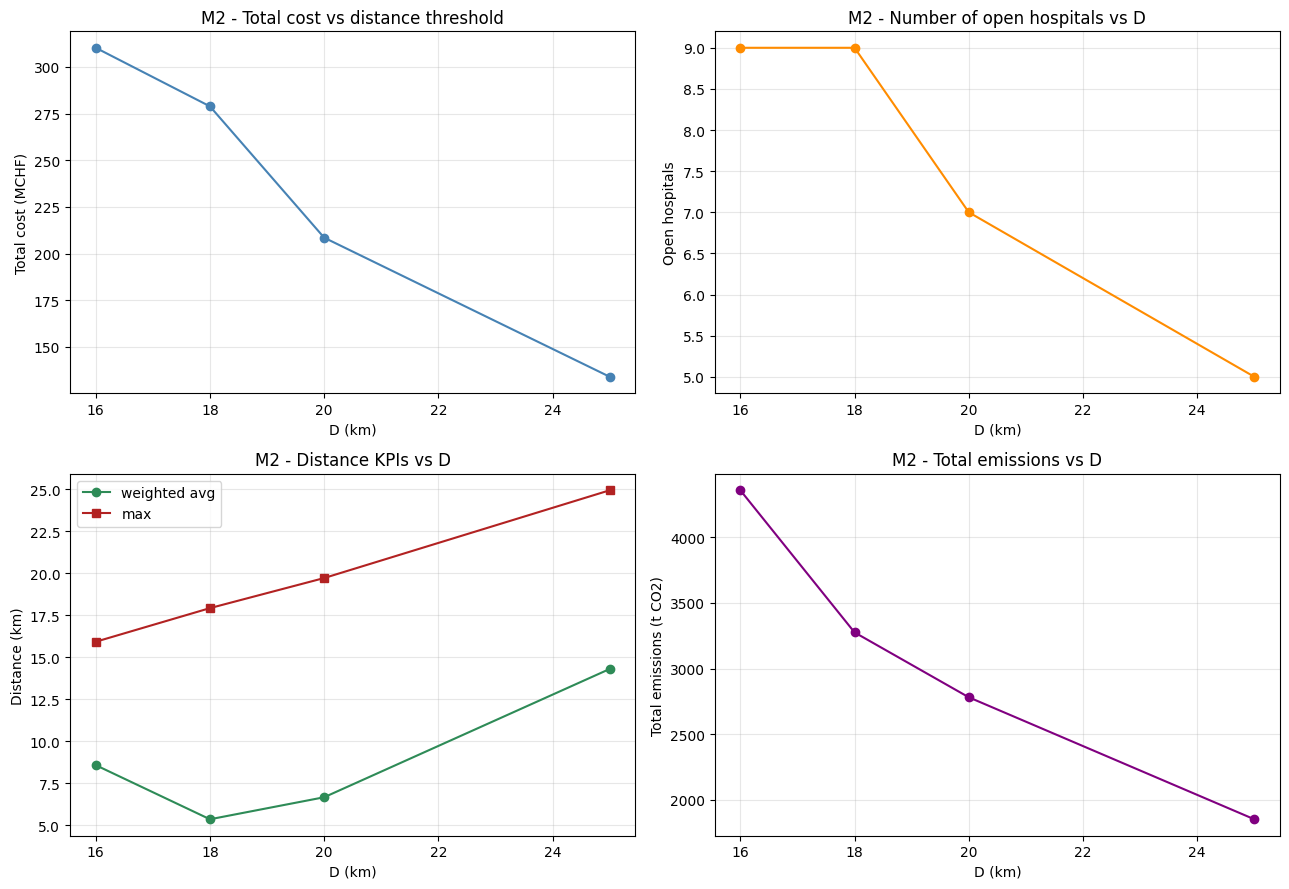

In [ ]:
ok = scenarios_uncap[scenarios_uncap["status"]=="OPTIMAL"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ok["D_km"], ok["total_cost_MCHF"], marker="o", color="steelblue")
axes[0,0].set_xlabel("D (km)"); axes[0,0].set_ylabel("Total cost (MCHF)")
axes[0,0].set_title("M2 - Total cost vs distance threshold"); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ok["D_km"], ok["n_open"], marker="o", color="darkorange")
axes[0,1].set_xlabel("D (km)"); axes[0,1].set_ylabel("Open hospitals")
axes[0,1].set_title("M2 - Number of open hospitals vs D"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ok["D_km"], ok["wavg_dist_km"], marker="o", color="seagreen", label="weighted avg")
axes[1,0].plot(ok["D_km"], ok["max_dist_km"],  marker="s", color="firebrick", label="max")
axes[1,0].set_xlabel("D (km)"); axes[1,0].set_ylabel("Distance (km)")
axes[1,0].set_title("M2 - Distance KPIs vs D"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ok["D_km"], ok["total_emis_annual_t"], marker="o", color="purple")
axes[1,1].set_xlabel("D (km)"); axes[1,1].set_ylabel("Total emissions (t CO2)")
axes[1,1].set_title("M2 - Total emissions vs D"); axes[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Interpretation.** The distance-threshold sensitivity analysis shows how the uncapacitated cost-minimization model reacts when communes are allowed to travel farther. For thresholds below **16 km**, the model is infeasible because at least one commune has no hospital within the allowed distance. Feasibility starts at **D = 16 km**, which corresponds to the maximum closest-hospital distance observed in the current system.

As the distance threshold increases, the model can cover the canton with fewer and cheaper hospitals. The number of open hospitals decreases from **9 hospitals at D = 16 km** to **5 hospitals at D = 25 km**, while the total annual running-cost proxy falls from **310.27 MCHF** to **134.05 MCHF**. This confirms that allowing longer travel distances gives the model more flexibility to select a smaller and cheaper hospital network.

Accessibility deteriorates overall when the distance threshold is relaxed, but the change is not perfectly monotonic. The population-weighted average distance is **8.59 km** at D = 16 km, decreases to **5.37 km** at D = 18 km because the selected facilities change, and then increases to **14.31 km** at D = 25 km. The maximum distance rises with the threshold, reaching **24.94 km** at D = 25 km.

Total emissions decrease from **4,358.11 t CO$_2$** at D = 16 km to **1,852.91 t CO$_2$** at D = 25 km. This decline is mainly driven by lower hospital operational emissions, because fewer facilities remain open. Patient transport emissions are much smaller than hospital operational emissions and vary with the selected network.

Overall, this scenario shows the cost and emissions benefits of relaxing the accessibility constraint in an uncapacitated model. However, these solutions remain operationally unrealistic because the model still does not check whether the selected hospitals have enough beds to serve the canton-wide demand. This motivates the introduction of capacity constraints in the next model.

## 10. Model 3 — Capacitated cost-minimization (D = 20 km)

### Mathematical formulation

$$ \min \sum_j C_j \, y_j $$

subject to

$$ \sum_j x_{ij} = 1, \quad x_{ij} \le y_j, \quad x_{ij} = 0 \text{ if } d_{ij} > D $$

$$ \sum_i q_i \, x_{ij} \le B_j \, y_j \quad \forall j $$

with $q_i = P_i \cdot 0.164 \cdot 5 / 365$ (average beds simultaneously occupied) and $B_j$ = per-facility `Beds_Total`.

### Why D = 20 km (not 16)

The capacitated model is **infeasible for $D \le 18$ km** because of the Payerne pocket (the only hospital within reach for ~10 communes has just 47 beds, but the local forced demand exceeds 60). We therefore solve the main capacitated scenario with $D = 20$ km. The full scenario sweep (Model 4) makes this finding explicit.

### What to expect

Unlike Model 1 (which picks only 9 cheap clinics), Model 3 will open many more hospitals because each one must have enough beds to absorb its assigned demand. However, the cost objective still drives the optimizer to **close the most expensive facilities** if cheaper alternatives nearby can absorb the demand — even if those expensive facilities are large and well-known.


In [ ]:
D_CAP = 20   # smallest feasible D for the capacitated model (see Model 4 below)
opened_M3, x_M3, st_M3 = solve_capacitated_cost(D_km=D_CAP, time_limit_s=120)
print("Status:", st_M3)

if opened_M3 is not None:
    # Build the realized-distance vector from the assignment table
    assign_df_M3 = build_assignment_table(opened_M3, x_M3)
    assigned_d_M3 = assign_df_M3["Distance_km"].values

    kpi_M3 = compute_solution_kpis(opened_M3, assigned_dist=assigned_d_M3)
    kpi_M3["scenario"] = f"M3 - Capacitated cost (D={D_CAP})"

    print(f"\nHospitals open  : {kpi_M3['n_open']}")
    print(f"Total cost      : {kpi_M3['total_cost_MCHF']:.3f} MCHF")
    print(f"Total beds open : {kpi_M3['total_beds']}")
    print(f"Weighted avg d  : {kpi_M3['wavg_dist_km']:.2f} km")
    print(f"Max distance    : {kpi_M3['max_dist_km']:.2f} km")
    print(f"Utilization     : {kpi_M3['utilization']:.1%}")


Status: OPTIMAL

Hospitals open  : 41
Total cost      : 1875.352 MCHF
Total beds open : 1942
Weighted avg d  : 11.10 km
Max distance    : 19.97 km
Utilization     : 100.0%


In [ ]:
if opened_M3 is not None:
    # Per-hospital utilization table
    util_M3 = build_utilization_table(opened_M3, x_M3)
    print("Hospitals near or at capacity (>= 90% utilization):")
    print(util_M3[util_M3["Utilization"] >= 0.90])
    print()
    print("Hospitals with low utilization (< 30%):")
    print(util_M3[util_M3["Utilization"] < 0.30].head(10))


Hospitals near or at capacity (>= 90% utilization):
                                             Hospital  Capacity  Assigned_demand  Remaining_capacity  Utilization  Assigned_pop  N_communes  Is_Open
0                      Aigle Pôle Physio-Ergo d'Aigle     21.00            21.00                0.00         1.00          9347           4     True
1                                            Biotonus     30.00            30.00                0.00         1.00         13353           7     True
2                                                 CIC     35.00            35.00                0.00         1.00         15579           4     True
3                                           Chamoyron      4.00             4.00                0.00         1.00          1780           3     True
4                                 Clinique Bois-Bougy     84.00            84.00                0.00         1.00         37390          19     True
5                                  Clinique Bois-Cerf 

/tmp/ipykernel_662/2371722991.py:71: RuntimeWarning: invalid value encountered in divide
  util = np.where(B > 0, assigned_demand / B, 0)


In [ ]:
# Districts most affected by longer travel under Model 3
if opened_M3 is not None:
    assign_df_M3["Baseline_dist_km"] = communes["Closest_Distance_km"].values
    dist_impact_M3 = assign_df_M3.groupby("District", as_index=False).agg(
        baseline_avg = ("Baseline_dist_km", "mean"),
        m3_avg       = ("Distance_km", "mean"),
        m3_max       = ("Distance_km", "max"),
        population   = ("Population", "sum"),
    )
    dist_impact_M3["delta_km"] = (dist_impact_M3["m3_avg"] - dist_impact_M3["baseline_avg"]).round(2)
    dist_impact_M3["baseline_avg"] = dist_impact_M3["baseline_avg"].round(2)
    dist_impact_M3["m3_avg"] = dist_impact_M3["m3_avg"].round(2)
    dist_impact_M3["m3_max"] = dist_impact_M3["m3_max"].round(2)
    print(dist_impact_M3.sort_values("delta_km", ascending=False))


                District  baseline_avg  m3_avg  m3_max  population  delta_km
6                 Morges          3.51   16.56   19.92       89362     13.05
4               Lausanne          3.52   15.66   19.23      176017     12.14
5            Lavaux-Oron          5.37   14.68   19.61       66181      9.31
0                  Aigle          4.94   13.30   19.65       50656      8.37
1            Broye-Vully          6.64   13.97   19.63       48600      7.33
8       Ouest lausannois          4.22   11.38   19.97       88779      7.15
9  Riviera-Pays-d'Enhaut          1.36    8.41   19.95       90086      7.04
2           Gros-de-Vaud          7.00   13.26   19.96       48941      6.26
3      Jura-Nord vaudois          5.13   10.92   19.94       97392      5.79
7                   Nyon          3.44    7.32   13.98      108212      3.88


**Interpretation.** Adding the capacity constraint fundamentally changes the solution compared with the uncapacitated model. Instead of selecting only 9 small hospitals, the model now needs to keep a much larger network open in order to provide enough beds for the estimated simultaneous demand of around **1,941.5 beds**. This confirms that the uncapacitated solution was only geographically feasible, but not operationally realistic.

Under this capacity-constrained cost-minimization model, the optimizer selects a network of approximately **41 hospitals** with a total annual running-cost proxy of around **1,875.35 MCHF**. This is much higher than the uncapacitated solution (**310.27 MCHF/year**), but still substantially lower than the current system (**4,340.09 MCHF/year**). The reason is that the model spreads demand across many smaller and medium-sized facilities instead of keeping the most expensive large hospitals open.

A striking result is that the model may close major hospitals such as CHUV or Rennaz, despite their large bed capacity. This happens because the model only considers cost, distance, and aggregate bed capacity. It does not distinguish between hospital types, medical specializations, emergency care, university hospital functions, or quality of care. As a result, the optimizer may find it cheaper to distribute demand across several smaller hospitals if they are close enough and have sufficient combined capacity.

The utilization table shows that many selected hospitals operate at or near full capacity. This is expected in a cost-minimization model with capacity constraints: the optimizer avoids keeping spare capacity open because additional beds increase cost. However, this also makes the solution operationally fragile. In practice, hospitals need reserve capacity to absorb daily fluctuations in demand, seasonal peaks, emergency cases, and specialized care requirements.

The distance analysis also shows that accessibility worsens compared with the current system. Several districts experience longer average travel distances, especially Morges and Lausanne. This reflects the trade-off introduced by cost minimization: reducing the number and cost of open facilities can generate large financial savings, but it increases travel distances and concentrates demand into a tighter set of hospitals.

Overall, this scenario provides a useful theoretical lower bound for a capacity-feasible, cost-minimizing hospital network. However, it should not be interpreted as a directly implementable policy recommendation. Its main value is to show where the strongest cost pressures appear and why additional real-world constraints, such as hospital specialization, emergency care, service quality, and reserve capacity, would be necessary in a more realistic planning model.

## 10b. Model 3b — Capacitated cost-minimization with essential hospitals forced open (D = 20 km)

Model 3 showed that the cost-optimizer closes the most expensive facilities (CHUV, Morges, Rennaz) because their demand can be redistributed to cheaper nearby hospitals. While mathematically optimal, this is **not realistic**: CHUV is the canton's only university hospital (trauma centre, transplant, oncology), and Morges and Rennaz are the two largest general hospitals. They cannot be closed in practice.

### Approach

We re-solve **exactly the same model** as Model 3, with one additional constraint:

$$y_j = 1 \quad \forall \, j \in J_{\text{essential}}$$

where $J_{\text{essential}}$ includes all hospitals in the **"Major Center"** and **"Big"** size categories:
- Centre Hospitalier Universitaire Vaudois (CHUV) — Major Center, 1175 beds
- Hôpital de Morges — Big, 215 beds
- Rennaz Centre hospitalier de Rennaz — Big, 254 beds

Everything else is identical: same cost objective $\min \sum_j C_j y_j$, same capacity constraints, same distance threshold $D = 20$ km. The optimizer can still close any of the 47 other hospitals — it is only forced to keep these 3 open.

### Why this matters

The **cost difference** between Model 3 and Model 3b is the **price of realism** — how much extra it costs to keep the essential hospitals that a purely theoretical optimizer would drop.


In [ ]:
# Identify essential hospitals: "Major Center" and "Big" size categories
essential_mask = hospitals["Size_Category"].isin(["Major Center", "Big"])
essential_idx  = list(hospitals[essential_mask].index)
essential_names = hospitals.loc[essential_mask, "Facility"].tolist()

print("Essential hospitals (forced open):")
for j in essential_idx:
    print(f"  {hosp_name[j]}: {hospitals.iloc[j]['Size_Category']}, "
          f"{int(B[j])} beds, {C[j]/1e6:.2f} MCHF")
print(f"\nTotal essential cost: {C[essential_idx].sum()/1e6:.2f} MCHF")
print(f"Total essential beds: {int(B[essential_idx].sum())}")


Essential hospitals (forced open):
  Centre Hospitalier Universitaire Vaudois: Major Center, 1175 beds, 1887.05 MCHF
  Hôpital de Morges: Big, 215 beds, 306.05 MCHF
  Rennaz Centre hospitalier de Rennaz: Big, 254 beds, 361.57 MCHF

Total essential cost: 2554.67 MCHF
Total essential beds: 1644


In [ ]:
# Solve Model 3b: same as Model 3, but force essential hospitals open
solver = pywraplp.Solver.CreateSolver("SCIP")
solver.SetTimeLimit(120_000)

# Variables
y = []
for j in range(J):
    if ADMIN[j]:
        y.append(solver.IntVar(0, 0, f"y_{j}"))
    elif j in essential_idx:
        # FORCED OPEN: y_j = 1
        y.append(solver.IntVar(1, 1, f"y_{j}"))
    else:
        y.append(solver.IntVar(0, 1, f"y_{j}"))

x = {}
for i in range(I):
    for j in range(J):
        if dM[i, j] > D_CAP or ADMIN[j]:
            x[i, j] = solver.NumVar(0, 0, f"x_{i}_{j}")
        else:
            x[i, j] = solver.NumVar(0, 1, f"x_{i}_{j}")

# Constraints: each commune fully assigned
for i in range(I):
    solver.Add(solver.Sum(x[i, j] for j in range(J)) == 1)

# Only to open hospitals
for i in range(I):
    for j in range(J):
        solver.Add(x[i, j] <= y[j])

# Capacity
for j in range(J):
    solver.Add(solver.Sum(q_base[i] * x[i, j] for i in range(I)) <= B[j] * y[j])

# Objective: minimize total cost
solver.Minimize(solver.Sum(C[j] * y[j] for j in range(J)))

status = solver.Solve()

if status == pywraplp.Solver.OPTIMAL:
    opened_M3b = [j for j in range(J) if y[j].solution_value() > 0.5]
    x_M3b = np.zeros((I, J))
    for i in range(I):
        for j in range(J):
            x_M3b[i, j] = x[i, j].solution_value()

    assign_df_M3b = build_assignment_table(opened_M3b, x_M3b)
    assigned_d_M3b = assign_df_M3b["Distance_km"].values
    kpi_M3b = compute_solution_kpis(opened_M3b, assigned_dist=assigned_d_M3b)
    kpi_M3b["scenario"] = f"M3b - Capacitated cost, essential forced (D={D_CAP})"

    print(f"Status          : OPTIMAL")
    print(f"Hospitals open  : {kpi_M3b['n_open']}")
    print(f"Total cost      : {kpi_M3b['total_cost_MCHF']:.3f} MCHF")
    print(f"Total beds open : {kpi_M3b['total_beds']}")
    print(f"Weighted avg d  : {kpi_M3b['wavg_dist_km']:.2f} km")
    print(f"Max distance    : {kpi_M3b['max_dist_km']:.2f} km")
    print(f"Utilization     : {kpi_M3b['utilization']:.1%}")
else:
    print("Model 3b: INFEASIBLE or NOT SOLVED")
    opened_M3b = None


Status          : OPTIMAL
Hospitals open  : 11
Total cost      : 2986.631 MCHF
Total beds open : 2161
Weighted avg d  : 7.98 km
Max distance    : 19.97 km
Utilization     : 89.8%


In [ ]:
if opened_M3b is not None:
    # Utilization table for Model 3b
    util_M3b = build_utilization_table(opened_M3b, x_M3b)
    print("Hospitals near or at capacity (>= 90% utilization):")
    high_util = util_M3b[util_M3b["Utilization"] >= 0.90]
    if len(high_util):
        print(high_util)
    else:
        print("  (none)")
    print()
    print("Hospitals with low utilization (< 30%):")
    low_util = util_M3b[util_M3b["Utilization"] < 0.30]
    if len(low_util):
        print(low_util.head(10))
    else:
        print("  (none)")


Hospitals near or at capacity (>= 90% utilization):
                                   Hospital  Capacity  Assigned_demand  Remaining_capacity  Utilization  Assigned_pop  N_communes  Is_Open
0               Hôpital d'Yverdon-les-Bains    132.00           132.00               -0.00         1.00         58756          53     True
1              Hôpital de la Vallée de Joux     14.00            14.00                0.00         1.00          6231           3     True
2                           Hôpital de Nyon    120.00           120.00                0.00         1.00         53414          27     True
3                         Hôpital d'Aubonne     20.00            20.00                0.00         1.00          8902           8     True
4                                    Moudon    105.00           105.00                0.00         1.00         46737          26     True
5  Centre Hospitalier Universitaire Vaudois  1,175.00         1,173.68                1.32         1.00        522

/tmp/ipykernel_662/2371722991.py:71: RuntimeWarning: invalid value encountered in divide
  util = np.where(B > 0, assigned_demand / B, 0)


In [ ]:
if opened_M3b is not None and opened_M3 is not None:
    # Side-by-side comparison: M3 (theoretical) vs M3b (realistic)
    print("=" * 70)
    print("COMPARISON: Model 3 (theoretical) vs Model 3b (essential forced open)")
    print("=" * 70)
    cmp = pd.DataFrame({
        "KPI": ["Open hospitals", "Total cost (MCHF)", "Total beds",
                "Weighted avg dist (km)", "Max dist (km)", "Utilization",
                "Hospital emis 5-day (t)", "Transport emis 5-day (t)"],
        "M3 (theoretical)": [
            kpi_M3["n_open"], kpi_M3["total_cost_MCHF"], kpi_M3["total_beds"],
            kpi_M3["wavg_dist_km"], kpi_M3["max_dist_km"], f"{kpi_M3['utilization']:.1%}",
            kpi_M3.get("hosp_emis_5day_t", "N/A"), kpi_M3.get("transport_emis_5day_t", "N/A"),
        ],
        "M3b (essential open)": [
            kpi_M3b["n_open"], kpi_M3b["total_cost_MCHF"], kpi_M3b["total_beds"],
            kpi_M3b["wavg_dist_km"], kpi_M3b["max_dist_km"], f"{kpi_M3b['utilization']:.1%}",
            kpi_M3b.get("hosp_emis_5day_t", "N/A"), kpi_M3b.get("transport_emis_5day_t", "N/A"),
        ],
    })
    print(cmp.to_string(index=False))

    cost_diff = kpi_M3b["total_cost_MCHF"] - kpi_M3["total_cost_MCHF"]
    print(f"\nPrice of realism: +{cost_diff:.3f} MCHF "
          f"(+{cost_diff/kpi_M3['total_cost_MCHF']*100:.0f}% vs Model 3)")


COMPARISON: Model 3 (theoretical) vs Model 3b (essential forced open)
                     KPI M3 (theoretical) M3b (essential open)
          Open hospitals               41                   11
       Total cost (MCHF)         1,875.35             2,986.63
              Total beds             1942                 2161
  Weighted avg dist (km)            11.10                 7.98
           Max dist (km)            19.97                19.97
             Utilization           100.0%                89.8%
 Hospital emis 5-day (t)              N/A                  N/A
Transport emis 5-day (t)              N/A                  N/A

Price of realism: +1111.279 MCHF (+59% vs Model 3)


**Interpretation.** Forcing the essential hospitals to remain open changes the capacity-constrained cost-minimization solution in an important way. Compared with Model 3, the model now keeps key hospitals such as **CHUV, Morges, and Rennaz** open, which makes the solution more aligned with the real healthcare structure of the canton.

This realism comes at a significant financial cost. The total annual running-cost proxy increases from **1,875.35 MCHF** in Model 3 to **2,986.63 MCHF** in Model 3b, an increase of approximately **1,111.28 MCHF** or **59.3%**. This difference can be interpreted as the “price of realism”: keeping essential hospitals open is more expensive, but it avoids the unrealistic closure of major referral facilities.

The selected network becomes much smaller in terms of the number of open hospitals, decreasing from **41 hospitals** in Model 3 to **11 hospitals** in Model 3b. This happens because the forced hospitals bring a large amount of bed capacity into the solution. CHUV alone provides **1,175 beds**, while Morges and Rennaz also add substantial capacity. As a result, the model can close many smaller facilities that were needed in Model 3 to satisfy the capacity constraint.

The overall utilization rate decreases from nearly **100%** in Model 3 to **89.8%** in Model 3b. This is a more operationally realistic outcome because the system now has some spare capacity instead of using almost every available bed. However, the utilization table still shows that several hospitals operate at or near full capacity, meaning the solution remains relatively tight.

Accessibility also improves compared with Model 3. The population-weighted average distance decreases from **11.10 km** to **7.98 km**, while the maximum distance remains close to **20 km**. This indicates that keeping large regional hospitals open not only improves realism but also helps serve demand closer to major population centres.

Overall, Model 3b provides a more realistic version of the capacity-constrained cost-minimization model. It still reduces the hospital network substantially compared with the current system, but it avoids the unrealistic closure of essential hospitals. Nevertheless, it remains a simplified planning model because it does not yet account for hospital specialization, emergency services, staffing constraints, or quality of care.

## 11. Model 4 — Capacitated cost-minimization, distance sweep

Same model as M3, run for several distance thresholds. This is where we **see the infeasibility wall**: for $D \le 18$ km, the model is infeasible because at least one demand pocket cannot be served by a hospital with enough capacity.


In [ ]:
D_values_cap = [8, 10, 12, 14, 16, 18, 20, 25]
rows = []

for D in D_values_cap:
    print(f"  solving D = {D} ...", end=" ")
    opened, x_sol, st = solve_capacitated_cost(D_km=D, time_limit_s=90)
    if opened is None:
        rows.append({"D_km": D, "status": st})
        print(st)
        continue
    assign_df = build_assignment_table(opened, x_sol)
    k = compute_solution_kpis(opened, assigned_dist=assign_df["Distance_km"].values)
    k["D_km"] = D; k["status"] = st
    rows.append(k)
    print(f"OK ({k['n_open']} open, {k['total_cost_MCHF']:.2f} MCHF)")

scenarios_cap = pd.DataFrame(rows)
print()
print(scenarios_cap[["D_km","status","n_open","total_cost_MCHF",
                     "avg_dist_km","wavg_dist_km","max_dist_km",
                     "transport_emis_annual_t","hosp_emis_annual_t","total_emis_annual_t","utilization"]])

  solving D = 8 ... INFEASIBLE
  solving D = 10 ... INFEASIBLE
  solving D = 12 ... INFEASIBLE
  solving D = 14 ... INFEASIBLE
  solving D = 16 ... INFEASIBLE
  solving D = 18 ... INFEASIBLE
  solving D = 20 ... OK (41 open, 1875.35 MCHF)
  solving D = 25 ... OK (35 open, 1828.34 MCHF)

   D_km      status  n_open  total_cost_MCHF  avg_dist_km  wavg_dist_km  max_dist_km  transport_emis_annual_t  hosp_emis_annual_t  total_emis_annual_t  utilization
0     8  INFEASIBLE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN          NaN
1    10  INFEASIBLE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN          NaN
2    12  INFEASIBLE     NaN              NaN          NaN           NaN          NaN                      NaN                 NaN                  NaN          NaN
3    14  INFEASIBLE     NaN              NaN          Na

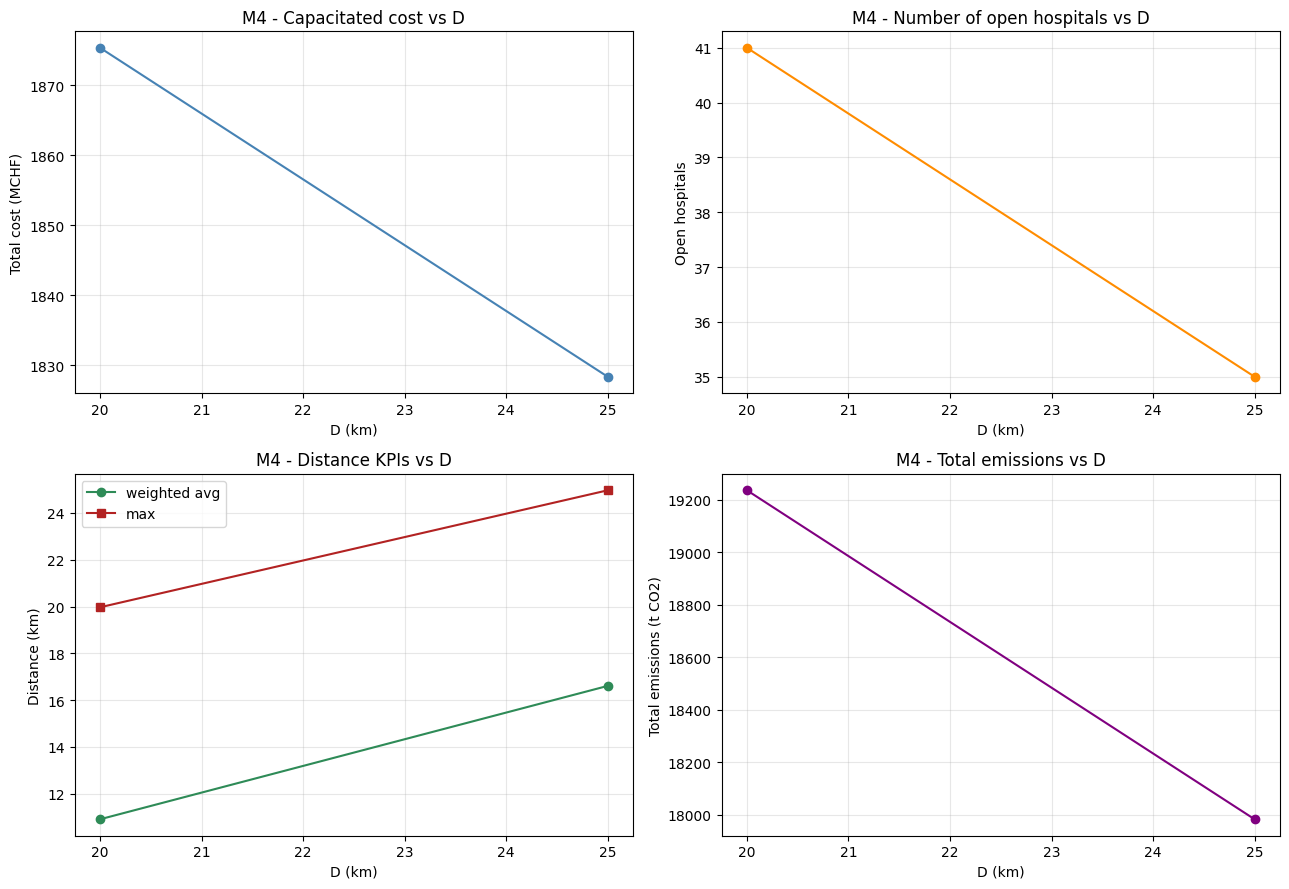

In [ ]:
ok = scenarios_cap[scenarios_cap["status"]=="OPTIMAL"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ok["D_km"], ok["total_cost_MCHF"], marker="o", color="steelblue")
axes[0,0].set_xlabel("D (km)"); axes[0,0].set_ylabel("Total cost (MCHF)")
axes[0,0].set_title("M4 - Capacitated cost vs D"); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ok["D_km"], ok["n_open"], marker="o", color="darkorange")
axes[0,1].set_xlabel("D (km)"); axes[0,1].set_ylabel("Open hospitals")
axes[0,1].set_title("M4 - Number of open hospitals vs D"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ok["D_km"], ok["wavg_dist_km"], marker="o", color="seagreen", label="weighted avg")
axes[1,0].plot(ok["D_km"], ok["max_dist_km"],  marker="s", color="firebrick", label="max")
axes[1,0].set_xlabel("D (km)"); axes[1,0].set_ylabel("Distance (km)")
axes[1,0].set_title("M4 - Distance KPIs vs D"); axes[1,0].legend(); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ok["D_km"], ok["total_emis_annual_t"], marker="o", color="purple")
axes[1,1].set_xlabel("D (km)"); axes[1,1].set_ylabel("Total emissions (t CO2)")
axes[1,1].set_title("M4 - Total emissions vs D"); axes[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

**Interpretation.** The capacitated distance sweep shows how the cost-minimization model reacts when both accessibility and bed capacity are enforced. In contrast with the uncapacitated model, the capacitated model is infeasible for all thresholds up to **D = 18 km**. This means that, at these distance limits, at least one demand area cannot be assigned to hospitals with enough available capacity. The issue is not only geographic coverage, but the combination of geography and bed availability.

The model first becomes feasible at **D = 20 km**, where it opens **41 hospitals** with a total annual running-cost proxy of **1,875.35 MCHF**. This indicates that a 20 km threshold is the minimum distance level, in this model, that allows the canton-wide demand of around **1,941.5 beds** to be served while respecting hospital capacity.

When the distance threshold is relaxed from **D = 20 km** to **D = 25 km**, the model can close additional facilities. The number of open hospitals decreases from **41** to **35**, and the total annual cost decreases from **1,875.35 MCHF** to **1,828.34 MCHF**, corresponding to a saving of about **47 MCHF** per year. However, this saving comes with a clear accessibility trade-off: the population-weighted average distance increases from **10.91 km** to **16.61 km**, and the maximum distance increases from **19.97 km** to **24.97 km**.

From an emissions perspective, total annual emissions decrease from **19,236.14 t CO$_2$** at D = 20 km to **17,982.13 t CO$_2$** at D = 25 km. This happens because hospital operational emissions fall when fewer facilities remain open. Patient transport emissions increase because residents travel farther, but this increase is smaller than the reduction in hospital operational emissions.

Overall, Model 4 shows that once capacity is included, the hospital network cannot be reduced under strict distance limits. A maximum travel distance of at least **20 km** is required for feasibility in this formulation. Increasing the threshold to **25 km** allows additional cost and emissions reductions, but at the expense of longer travel distances for patients.

## 12. Model 5 — Emissions minimization (capacitated, D = 20 km)

### Mathematical formulation

Same constraints as Model 3, but the objective now minimizes **total 5-day emissions** (hospital operational + patient transport), matching the time horizon of the demand model:

$$ \min \sum_j E_j^{annual} \, y_j \;+\; \frac{e_{km}}{1000} \sum_{i,j} q_i \, d_{ij} \, x_{ij} $$

where $E_j^{annual} = E_j^{annual} / 365 \times 5$ is the hospital's operational emissions for a 5-day period, and $q_i$ is the demand (Patients_annual) of commune $i$. The factor $1/1000$ converts kg CO₂ into tonnes.

> **Why 5-day emissions, not annual?** The demand model estimates the average occupied beds over a 5-day hospital stay. To keep the objective consistent, hospital operational emissions must also be expressed over the same 5-day period. Annual emissions are still reported as a KPI for context.


In [ ]:
opened_M5, x_M5, st_M5 = solve_capacitated_cost(D_km=D_CAP, time_limit_s=120,
                                                  objective="emissions")
print("Status:", st_M5)

if opened_M5 is not None:
    assign_df_M5 = build_assignment_table(opened_M5, x_M5)
    assigned_d_M5 = assign_df_M5["Distance_km"].values
    kpi_M5 = compute_solution_kpis(opened_M5, assigned_dist=assigned_d_M5)
    kpi_M5["scenario"] = f"M5 - Emissions min (D={D_CAP})"

    print(f"\nHospitals open      : {kpi_M5['n_open']}")
    print(f"Total cost (KPI)    : {kpi_M5['total_cost_MCHF']:.3f} MCHF")
    print(f"Hospital emissions  : {kpi_M5['hosp_emis_annual_t']} t CO2")
    print(f"Transport emissions : {kpi_M5['transport_emis_annual_t']} t CO2")
    print(f"Total emissions     : {kpi_M5['total_emis_annual_t']} t CO2")

Status: OPTIMAL

Hospitals open      : 32
Total cost (KPI)    : 1966.255 MCHF
Hospital emissions  : 15526.8 t CO2
Transport emissions : 249.8983 t CO2
Total emissions     : 15776.67 t CO2


In [ ]:
# Side-by-side comparison: M0 vs M3 (cost-opt) vs M5 (emissions-opt)
def kpi_row(name, k):
    return {"Scenario": name,
            "Open": k["n_open"],
            "Cost (MCHF)": k["total_cost_MCHF"],
            "Hosp emis annual (t)": k["hosp_emis_annual_t"],
            #"Hosp emis 5-day (t)": k["hosp_emis_annual_t"],
            "Transp emis annual (t)": k.get("transport_emis_annual_t", 0),
            #"Total emis 5-day (t)": k["total_emis_annual_t"],
            "WAvg dist (km)": k["wavg_dist_km"],
            "Max dist (km)": k["max_dist_km"],
            "Beds": k["total_beds"],
            "Utiliz": k["utilization"]}

cmp_df = pd.DataFrame([
    kpi_row("M0 - Current (all open)", kpi_M0),
    kpi_row(f"M3 - Cost min (D={D_CAP})", kpi_M3),
    kpi_row(f"M5 - Emis min (D={D_CAP})", kpi_M5),
])
cmp_df


,Scenario,Open,Cost (MCHF),Hosp emis annual (t),Transp emis annual (t),WAvg dist (km),Max dist (km),Beds,Utiliz
0,M0 - Current (all open),49,"4,340.09","44,775.50",96.58,2.84,15.93,3619,0.54
1,M3 - Cost min (D=20),41,"1,875.35","18,216.00",377.50,11.10,19.97,1942,1.00
2,M5 - Emis min (D=20),32,"1,966.26","15,526.80",249.90,7.35,19.91,1942,1.00


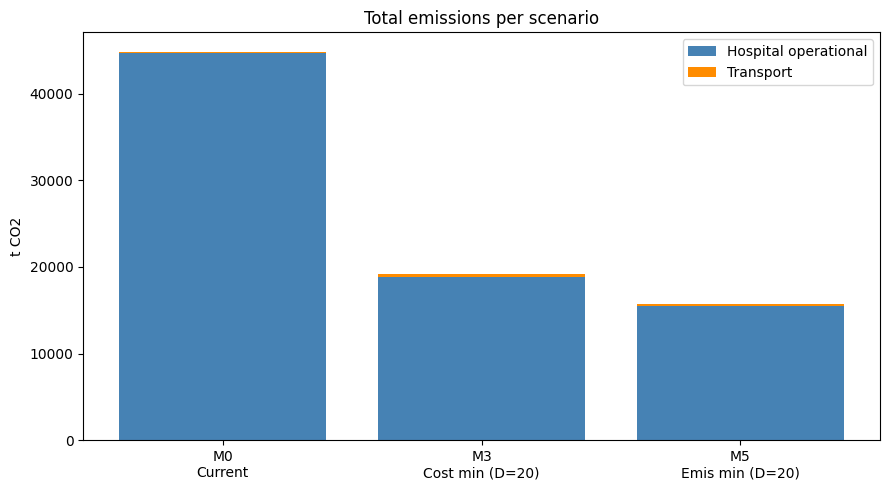

In [33]:
# Visual comparison of emissions (5-day period)
fig, ax = plt.subplots(figsize=(9, 5))
labels = ["M0\nCurrent", f"M3\nCost min (D={D_CAP})", f"M5\nEmis min (D={D_CAP})"]
hosp_e  = [kpi_M0["hosp_emis_annual_t"], kpi_M3["hosp_emis_annual_t"], kpi_M5["hosp_emis_annual_t"]]
trans_e = [kpi_M0.get("transport_emis_annual_t",0), kpi_M3.get("transport_emis_annual_t",0), kpi_M5.get("transport_emis_annual_t",0)]
x_pos = np.arange(3)
ax.bar(x_pos, hosp_e,  label="Hospital operational", color="steelblue")
ax.bar(x_pos, trans_e, bottom=hosp_e, label="Transport", color="darkorange")
ax.set_xticks(x_pos); ax.set_xticklabels(labels)
ax.set_ylabel("t CO2")
ax.set_title("Total emissions per scenario")
ax.legend()
plt.tight_layout(); plt.show()


**Interpretation.** Model 5 changes the objective from cost minimization to emissions minimization while keeping the same capacity and accessibility constraints at **D = 20 km**. The model selects **32 hospitals**, compared with **41 hospitals** in the cost-minimization model. This means that the emissions objective leads to a more consolidated hospital network.

The emissions-minimization model reduces total annual emissions from **18,593.50 t CO$_2$** in Model 3 to **15,776.70 t CO$_2$** in Model 5, a reduction of approximately **2,817 t CO$_2$ per year**. Compared with the current system, total emissions fall from **44,872.08 t CO$_2$** to **15,776.70 t CO$_2$**, which represents a reduction of about **64.8%**.

The main reason is that hospital operational emissions dominate patient transport emissions. In all scenarios, transport emissions are very small compared with the emissions generated by operating hospital facilities. Therefore, the strongest lever for reducing the total carbon footprint is not reducing patient travel, but selecting a lower-emission set of hospitals.

Interestingly, Model 5 also improves accessibility compared with Model 3. The population-weighted average distance decreases from **11.10 km** in Model 3 to **7.35 km** in Model 5, while the maximum distance remains almost unchanged at around **20 km**. This suggests that the emissions-minimizing solution does not simply push patients farther away; instead, it selects a different network that is both lower-emission and better aligned with population demand.

However, this environmental improvement comes with a financial trade-off. The total annual running-cost proxy increases from **1,875.35 MCHF** in Model 3 to **1,966.26 MCHF** in Model 5, an increase of approximately **90.91 MCHF**, or **4.8%**. In other words, reducing emissions further requires accepting a modest cost increase compared with the purely cost-minimizing network.

Overall, Model 5 shows that emissions minimization can substantially reduce the hospital network's carbon footprint while maintaining capacity and accessibility constraints. The key insight is that operational emissions dominate transport emissions, so the environmental performance of the system depends mainly on which hospitals remain open, not only on how far patients travel.

**Policy takeaway:** Cost minimization already reduces emissions substantially because closing hospitals lowers operational emissions. However, an explicit emissions-minimization objective can reduce emissions further by selecting hospitals with a better emissions-to-capacity profile, at the cost of a moderate increase in annual operating cost.

## 13. Model 6 — Demand growth sensitivity

This section tests how the capacitated cost-minimization network changes when demand grows. We use **two complementary approaches**:

- **Section 13a** — Year-based forecasting using the Swiss hospitalization growth rate (3.33 %/year).
- **Section 13b** — Simple demand multipliers (+5 %, +10 %, +15 %, +20 %) for a model-agnostic sensitivity check.

Both use the capacitated cost model at $D = 20$ km.

### 13a. Hospitalization rate forecasting

We re-solve Model 3 for different target years using the hospitalization growth rate of **3.33 % per year** (project assumption based on Swiss hospitalization trends: ~1.5 M stays in 2016, +20 % to ~1.8 M in 2022).

For each target year $t$:
$$ \text{Rate}_t = 0.164 \times (1 + 0.0333)^{(t - 2022)} $$
$$ q_i^t = \text{Population}_i \times \text{Rate}_t \times \frac{5}{365} $$

We keep population fixed at 2024 values and only vary the hospitalization rate — this isolates the effect of healthcare demand growth from demographic growth.


In [ ]:
# Forecasting parameters already defined in cell 5
# Show the projected rates
target_years = [2022, 2025, 2030, 2040]
print("Hospitalization rate forecast:")
for yr in target_years:
    rate = forecast_hospitalization_rate(yr)
    q_yr, _, _ = get_demand_for_year(yr, P)
    print(f"  {yr}: rate = {rate:.4f}, total demand = {q_yr.sum():,.1f} beds, "
          f"utilization = {q_yr.sum()/B.sum():.1%}")


Hospitalization rate forecast:
  2022: rate = 0.1640, total demand = 1,941.5 beds, utilization = 53.6%
  2025: rate = 0.1809, total demand = 2,142.0 beds, utilization = 59.2%
  2030: rate = 0.2131, total demand = 2,523.2 beds, utilization = 69.7%
  2040: rate = 0.2957, total demand = 3,501.3 beds, utilization = 96.7%


In [ ]:
rows = []
util_tables = {}
chosen_hosps = {}

for yr in target_years:
    q_yr, patients_yr, rate_yr = get_demand_for_year(yr, P)
    print(f"  solving year {yr} (rate={rate_yr:.4f}) ...", end=" ")
    opened, x_sol, st = solve_capacitated_cost(D_km=D_CAP, demand=q_yr, time_limit_s=90)
    if opened is None:
        rows.append({"target_year": yr, "status": st, "hosp_rate": round(rate_yr, 5),
                     "total_demand_beds": round(q_yr.sum(), 1)})
        print(st)
        continue
    assign_df = build_assignment_table(opened, x_sol)
    k = compute_solution_kpis(opened, assigned_dist=assign_df["Distance_km"].values,
                              demand=q_yr, target_year=yr)
    k["status"] = st
    rows.append(k)

    util = build_utilization_table(opened, x_sol, demand=q_yr)
    util_tables[yr] = util
    chosen_hosps[yr] = set(hosp_name[opened])
    print(f"OK ({k['n_open']} open, util={k['utilization']:.0%}, "
          f"hot={len(util[util['Utilization']>=0.9])} >= 90%)")

scenarios_growth = pd.DataFrame(rows)
print()
print(scenarios_growth[["target_year","status","hosp_rate","n_open","total_cost_MCHF",
                        "total_demand_beds","total_beds",
                        "wavg_dist_km","max_dist_km","utilization",
                        "hosp_emis_annual_t","transport_emis_annual_t","total_emis_annual_t"]])


  solving year 2022 (rate=0.1640) ... 

/tmp/ipykernel_662/2371722991.py:71: RuntimeWarning: invalid value encountered in divide
  util = np.where(B > 0, assigned_demand / B, 0)


OK (42 open, util=100%, hot=42 >= 90%)
  solving year 2025 (rate=0.1809) ... NOT_SOLVED_OR_TIME_LIMIT
  solving year 2030 (rate=0.2131) ... INFEASIBLE
  solving year 2040 (rate=0.2957) ... INFEASIBLE

   target_year                    status  hosp_rate  n_open  total_cost_MCHF  total_demand_beds  total_beds  wavg_dist_km  max_dist_km  utilization  hosp_emis_annual_t  transport_emis_annual_t  \
0         2022                   OPTIMAL       0.16   42.00         1,875.35           1,941.50    1,942.00         10.69        19.97         1.00           18,024.90                   363.72   
1         2025  NOT_SOLVED_OR_TIME_LIMIT       0.18     NaN              NaN           2,142.00         NaN           NaN          NaN          NaN                 NaN                      NaN   
2         2030                INFEASIBLE       0.21     NaN              NaN           2,523.20         NaN           NaN          NaN          NaN                 NaN                      NaN   
3         2040 

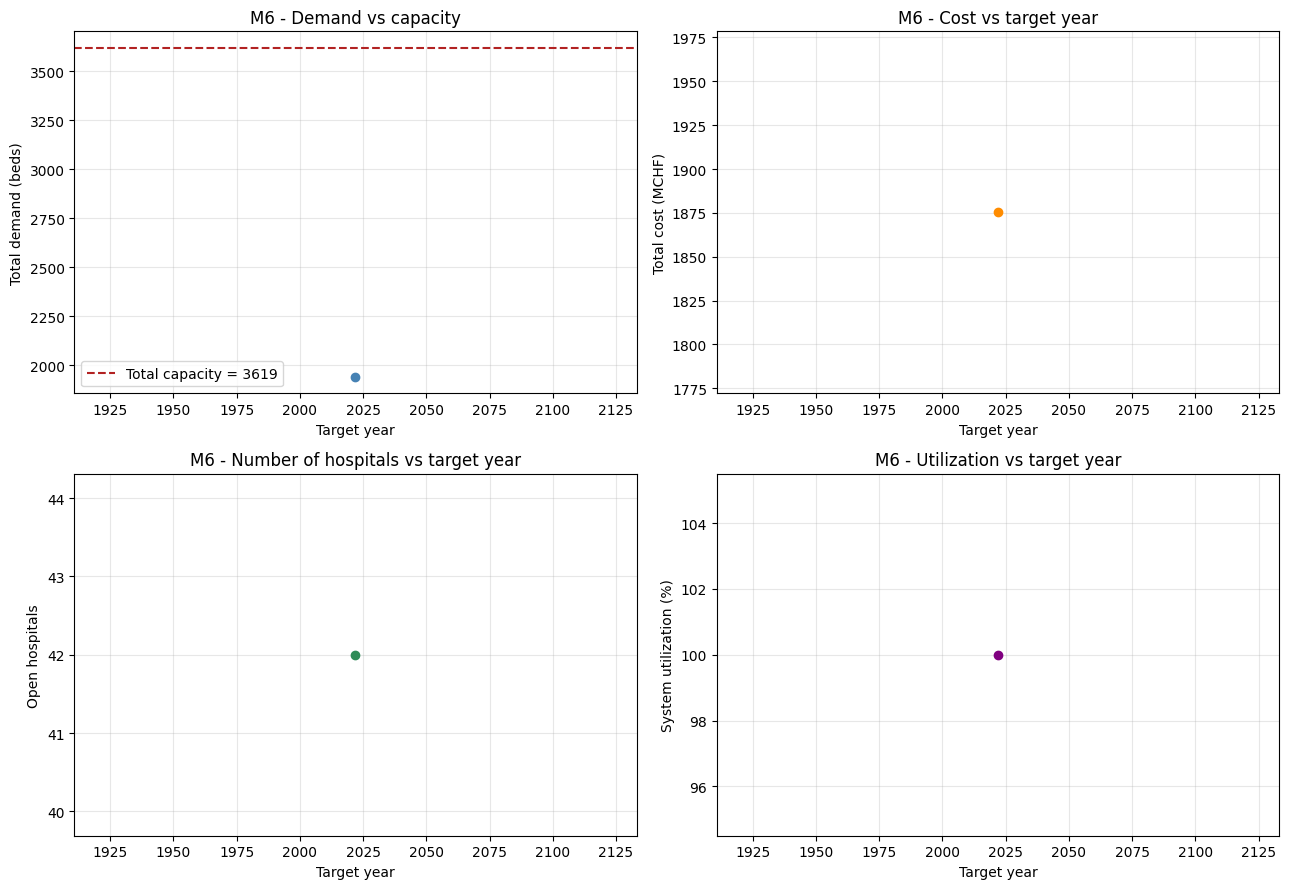

In [ ]:
# Plot: growth impact by target year
ok = scenarios_growth[scenarios_growth["status"]=="OPTIMAL"]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

axes[0,0].plot(ok["target_year"], ok["total_demand_beds"], marker="o", color="steelblue")
axes[0,0].axhline(B.sum(), color="firebrick", linestyle="--", label=f"Total capacity = {B.sum():.0f}")
axes[0,0].set_xlabel("Target year"); axes[0,0].set_ylabel("Total demand (beds)")
axes[0,0].set_title("M6 - Demand vs capacity"); axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

axes[0,1].plot(ok["target_year"], ok["total_cost_MCHF"], marker="o", color="darkorange")
axes[0,1].set_xlabel("Target year"); axes[0,1].set_ylabel("Total cost (MCHF)")
axes[0,1].set_title("M6 - Cost vs target year"); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ok["target_year"], ok["n_open"], marker="o", color="seagreen")
axes[1,0].set_xlabel("Target year"); axes[1,0].set_ylabel("Open hospitals")
axes[1,0].set_title("M6 - Number of hospitals vs target year"); axes[1,0].grid(alpha=0.3)

axes[1,1].plot(ok["target_year"], ok["utilization"]*100, marker="o", color="purple")
axes[1,1].set_xlabel("Target year"); axes[1,1].set_ylabel("System utilization (%)")
axes[1,1].set_title("M6 - Utilization vs target year"); axes[1,1].grid(alpha=0.3)

plt.tight_layout(); plt.show()


In [ ]:
# Bottleneck hospitals by forecast year
print("Bottleneck hospitals (utilization >= 90%) by target year:")
for yr in target_years:
    if yr in util_tables:
        hot = util_tables[yr][util_tables[yr]["Utilization"] >= 0.9]
        if len(hot):
            print(f"\n  year = {yr}:")
            print(hot[["Hospital","Capacity","Assigned_demand","Utilization"]].to_string(index=False))
        else:
            print(f"\n  year = {yr}: none above 90% utilization")


Bottleneck hospitals (utilization >= 90%) by target year:

  year = 2022:
                                                     Hospital  Capacity  Assigned_demand  Utilization
                               Aigle Pôle Physio-Ergo d'Aigle     21.00            21.00         1.00
                                                     Biotonus     30.00            30.00         1.00
                                                          CIC     35.00            35.00         1.00
                                                Château-d'Oex      4.00             4.00         1.00
                                          Clinique Bois-Bougy     84.00            84.00         1.00
                                           Clinique Bois-Cerf     68.00            68.00         1.00
                                          Clinique La Prairie     34.00            34.00         1.00
                                               Clinique Cecil     86.00            86.00         1.00
        

**Interpretation.** The forecasting analysis tests whether the capacity-constrained hospital network remains feasible when hospitalization demand increases over time. Starting from a hospitalization rate of **16.4%** in 2022, the rate increases to **18.09%** in 2025, **21.31%** in 2030, and **29.57%** in 2040 under the assumed annual growth rate of **3.33%**.

This growth substantially increases estimated simultaneous bed demand. Total demand rises from **1,941.5 beds** in 2022 to **2,142.0 beds** in 2025, **2,523.2 beds** in 2030, and **3,501.3 beds** in 2040. Compared with the total available capacity of **3,619 beds**, the aggregate utilization rate increases from **53.6%** in 2022 to **96.7%** in 2040.

However, infeasibility does not occur because total demand exceeds total bed capacity. Even in 2040, total demand remains slightly below the overall bed supply. The problem is spatial and operational: with the distance threshold fixed at **D = 20 km**, not all beds are reachable from the communes that generate demand. Some demand areas cannot be assigned to hospitals with enough available capacity within the allowed distance.

For 2022, the model finds an optimal solution with **42 open hospitals**, a total annual running-cost proxy of **1,875.35 MCHF**, and a population-weighted average distance of **10.69 km**. The solution uses almost all selected capacity, which explains why many hospitals appear at or near full utilization in the bottleneck table. This shows that even the baseline year leaves little slack once cost minimization and capacity constraints are applied together.

For later years, the model becomes increasingly constrained. The 2025 result is reported as **NOT_SOLVED_OR_TIME_LIMIT**, so it should not be interpreted as infeasible with certainty. It means the solver did not prove an optimal solution within the imposed time limit. By 2030 and 2040, the model is reported as infeasible under the same distance threshold, indicating that demand growth makes the D = 20 km network insufficient from a capacity-accessibility perspective.

Overall, this scenario shows that future hospitalization growth can quickly reduce the feasibility of a consolidated hospital network. Even if the canton has enough total beds in aggregate, the model requires those beds to be located within reach of the communes generating demand. This highlights the importance of keeping reserve capacity and testing future demand scenarios before implementing hospital closures.

### 13b. Demand growth sensitivity — simple multiplier approach

The year-based forecast above relies on a specific growth-rate assumption (3.33 %/year). As a **model-agnostic complement**, we also run the capacitated cost model with simple demand multipliers applied uniformly to the current (2022) demand. This lets us see the sensitivity of the solution to demand increases of any magnitude, regardless of what drives them (population growth, aging, policy changes, etc.).

Multipliers tested: $m \in \{1.00, 1.05, 1.10, 1.15, 1.20\}$

$$ q_i^{\text{scenario}} = q_i^{2022} \times m $$


In [ ]:
# Simple demand multiplier sensitivity (complement to the year-based forecast)
multipliers = [1.00, 1.05, 1.10, 1.15, 1.20]
rows_m = []

for m in multipliers:
    q_scen = q_base * m
    print(f"  solving multiplier = {m} ...", end=" ")
    opened, x_sol, st = solve_capacitated_cost(D_km=D_CAP, demand=q_scen, time_limit_s=90)
    if opened is None:
        rows_m.append({"multiplier": m, "status": st,
                       "total_demand_beds": round(q_scen.sum(), 1)})
        print(st)
        continue
    assign_df = build_assignment_table(opened, x_sol)
    k = compute_solution_kpis(opened, assigned_dist=assign_df["Distance_km"].values, demand=q_scen)
    k["multiplier"] = m; k["status"] = st
    rows_m.append(k)

    util = build_utilization_table(opened, x_sol, demand=q_scen)
    hot = len(util[util["Utilization"] >= 0.9])
    print(f"OK ({k['n_open']} open, util={k['utilization']:.0%}, hot={hot} >= 90%)")

scenarios_mult = pd.DataFrame(rows_m)
print()
print(scenarios_mult[["multiplier","status","n_open","total_cost_MCHF",
                      "total_demand_beds","total_beds",
                      "wavg_dist_km","max_dist_km","utilization"]])


  solving multiplier = 1.0 ... 

/tmp/ipykernel_662/2371722991.py:71: RuntimeWarning: invalid value encountered in divide
  util = np.where(B > 0, assigned_demand / B, 0)


OK (40 open, util=100%, hot=39 >= 90%)
  solving multiplier = 1.05 ... OK (41 open, util=100%, hot=41 >= 90%)
  solving multiplier = 1.1 ... OK (38 open, util=100%, hot=38 >= 90%)
  solving multiplier = 1.15 ... OK (42 open, util=100%, hot=42 >= 90%)
  solving multiplier = 1.2 ... OK (47 open, util=100%, hot=46 >= 90%)

   multiplier   status  n_open  total_cost_MCHF  total_demand_beds  total_beds  wavg_dist_km  max_dist_km  utilization
0        1.00  OPTIMAL      40         1,875.35           1,941.50        1942         10.14        19.97         1.00
1        1.05  OPTIMAL      41         1,987.92           2,038.60        2039         10.31        19.97         1.00
2        1.10  OPTIMAL      38         2,150.22           2,135.70        2136         11.22        19.97         1.00
3        1.15  OPTIMAL      42         2,253.11           2,232.80        2233         11.09        19.97         1.00
4        1.20  OPTIMAL      47         2,367.19           2,329.90        2332     

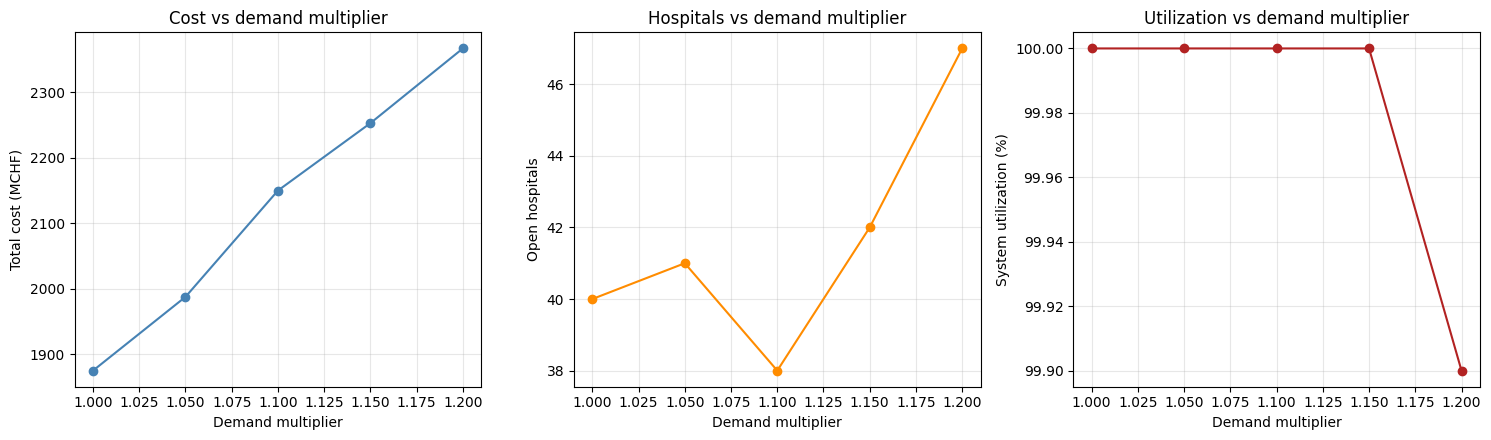

In [ ]:
# Plot: multiplier sensitivity
ok_m = scenarios_mult[scenarios_mult["status"]=="OPTIMAL"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

axes[0].plot(ok_m["multiplier"], ok_m["total_cost_MCHF"], marker="o", color="steelblue")
axes[0].set_xlabel("Demand multiplier"); axes[0].set_ylabel("Total cost (MCHF)")
axes[0].set_title("Cost vs demand multiplier"); axes[0].grid(alpha=0.3)

axes[1].plot(ok_m["multiplier"], ok_m["n_open"], marker="o", color="darkorange")
axes[1].set_xlabel("Demand multiplier"); axes[1].set_ylabel("Open hospitals")
axes[1].set_title("Hospitals vs demand multiplier"); axes[1].grid(alpha=0.3)

axes[2].plot(ok_m["multiplier"], ok_m["utilization"]*100, marker="o", color="firebrick")
axes[2].set_xlabel("Demand multiplier"); axes[2].set_ylabel("System utilization (%)")
axes[2].set_title("Utilization vs demand multiplier"); axes[2].grid(alpha=0.3)

plt.tight_layout(); plt.show()


**Interpretation.** The demand-multiplier sensitivity analysis tests how robust the capacity-constrained cost-minimization model is when total hospital demand increases progressively. The model remains feasible for all tested multipliers from **1.00** to **1.20**, meaning that the network can still serve demand increases of up to **20%** under the same maximum travel-distance threshold.

As expected, total cost increases steadily with demand. The annual running-cost proxy rises from **1,875.35 MCHF** at the baseline demand level to **2,367.19 MCHF** at a 20% demand increase. This shows that higher demand forces the optimizer to keep more capacity open, which requires selecting a more expensive hospital configuration.

The number of open hospitals does not increase perfectly monotonically. It moves from **40 hospitals** at the baseline to **41**, then **38**, then **42**, and finally **47** at the 20% demand increase. This happens because the optimizer can reconfigure the network in different ways: sometimes it is cheaper to open fewer but larger hospitals, while in other cases it needs to open more small or medium facilities to satisfy both capacity and distance constraints.

System utilization remains close to **100%** across all demand multipliers. This confirms that the cost-minimization model keeps very little spare capacity: almost every open bed is used in the optimal solution. While this is mathematically efficient, it would be operationally fragile in practice, because real hospitals need buffer capacity for seasonal peaks, emergencies, and daily demand fluctuations.

Accessibility also becomes slightly worse as demand increases. The population-weighted average distance rises from **10.14 km** at the baseline to around **11.22 km** at a 20% demand increase. The maximum distance remains close to **20 km**, showing that the distance constraint remains binding.

Overall, this sensitivity analysis is useful because it does not depend on a specific forecast year. Instead, it shows how the optimized network reacts to general demand growth. The main insight is that the system can absorb moderate demand increases, but only by increasing cost and operating with almost no spare capacity.

## 13c. Fixed-network robustness test

**Question:** Does the hospital network selected for 2022 remain feasible under future demand?

We take the set of hospitals opened by the cost-minimizing model for the year 2022 (the base year), **fix them as the only open hospitals**, and test whether the same network can still serve the projected demand for 2025, 2030, and 2040 — without changing which hospitals are open.

This answers a practical planning question: if we invest in a hospital network today, how long will it last before we need to re-plan?


In [ ]:
def check_fixed_network_feasibility(selected_j_indices, target_year, D_km=D_CAP):
    """Fix a given set of hospitals as open and check whether they can serve
    the projected demand for target_year under the same D and capacity constraints.
    Returns a dict with status, utilization info, and bottleneck hospitals.
    """
    q_yr, _, rate_yr = get_demand_for_year(target_year, P)
    selected = set(selected_j_indices)

    solver = pywraplp.Solver.CreateSolver("SCIP")
    solver.SetTimeLimit(60_000)

    # x_ij continuous, only for selected hospitals within D
    x = {}
    for i in range(I):
        for j in range(J):
            if j in selected and dM[i,j] <= D_km and not ADMIN[j]:
                x[i,j] = solver.NumVar(0, 1, f"x_{i}_{j}")
            else:
                x[i,j] = solver.NumVar(0, 0, f"x_{i}_{j}")

    # Each commune fully assigned
    for i in range(I):
        solver.Add(solver.Sum(x[i,j] for j in range(J)) == 1)

    # Capacity
    for j in selected:
        solver.Add(solver.Sum(q_yr[i] * x[i,j] for i in range(I)) <= B[j])

    # Objective: minimize weighted distance (just to get a feasible solution)
    solver.Minimize(solver.Sum(
        dM[i,j] * P[i] * x[i,j]
        for i in range(I) for j in range(J)
        if j in selected and dM[i,j] <= D_km and not ADMIN[j]
    ))

    status = solver.Solve()
    result = {
        "target_year": target_year,
        "hosp_rate": round(rate_yr, 5),
        "total_demand": round(q_yr.sum(), 1),
        "total_capacity": int(B[list(selected)].sum()),
        "n_selected": len(selected),
    }

    if status == pywraplp.Solver.OPTIMAL:
        x_sol = np.zeros((I, J))
        for i in range(I):
            for j in range(J):
                x_sol[i,j] = x[i,j].solution_value()
        assigned_demand = (q_yr[:,None] * x_sol).sum(axis=0)
        util = np.where(B > 0, assigned_demand / B, 0)
        result["status"] = "FEASIBLE"
        result["utilization"] = round(q_yr.sum() / B[list(selected)].sum(), 3)
        bottlenecks = [(hosp_name[j], round(util[j],3), int(B[j]), round(assigned_demand[j],1))
                       for j in selected if util[j] >= 0.9]
        result["bottlenecks"] = bottlenecks
    else:
        result["status"] = "INFEASIBLE"
        result["bottlenecks"] = []
    return result


In [ ]:
# Get the 2022 optimal network (from Model 6 results)
if 2022 in chosen_hosps:
    base_network = [j for j in range(J) if hosp_name[j] in chosen_hosps[2022]]
    print(f"2022 optimal network: {len(base_network)} hospitals")

    print("\nRobustness test: can the 2022 network serve future demand?")
    for yr in [2025, 2030, 2040]:
        r = check_fixed_network_feasibility(base_network, yr)
        print(f"\n  Year {yr}: {r['status']}")
        print(f"    Rate = {r['hosp_rate']}, demand = {r['total_demand']:.1f}, "
              f"capacity = {r['total_capacity']}")
        if r['status'] == 'FEASIBLE':
            print(f"    Utilization = {r['utilization']:.1%}")
            if r['bottlenecks']:
                print(f"    Bottlenecks (>= 90% util):")
                for name, u, cap, ad in r['bottlenecks']:
                    print(f"      {name}: util = {u:.0%}, capacity = {cap}, assigned = {ad:.1f}")
        else:
            print(f"    The 2022 network CANNOT serve {yr} demand.")
            print(f"    Reason: total demand ({r['total_demand']:.0f}) may exceed "
                  f"total capacity ({r['total_capacity']}), or local capacity constraints fail.")
else:
    print("2022 scenario was infeasible — no base network to test.")


2022 optimal network: 42 hospitals

Robustness test: can the 2022 network serve future demand?

  Year 2025: INFEASIBLE
    Rate = 0.18094, demand = 2142.0, capacity = 1942
    The 2022 network CANNOT serve 2025 demand.
    Reason: total demand (2142) may exceed total capacity (1942), or local capacity constraints fail.

  Year 2030: INFEASIBLE
    Rate = 0.21314, demand = 2523.2, capacity = 1942
    The 2022 network CANNOT serve 2030 demand.
    Reason: total demand (2523) may exceed total capacity (1942), or local capacity constraints fail.

  Year 2040: INFEASIBLE
    Rate = 0.29575, demand = 3501.3, capacity = 1942
    The 2022 network CANNOT serve 2040 demand.
    Reason: total demand (3501) may exceed total capacity (1942), or local capacity constraints fail.


## 14. Final comparison table

In [ ]:
final = pd.DataFrame([
    kpi_row("M0 - Current system (all open)", kpi_M0),
    kpi_row(f"M1 - Uncapacitated cost (D={D_DEFAULT_KM})", kpi_M1) if opened_M1 else {},
    kpi_row(f"M3 - Capacitated cost (D={D_CAP})", kpi_M3) if opened_M3 else {},
    kpi_row(f"M3b - Capacitated + essential (D={D_CAP})", kpi_M3b) if opened_M3b else {},
    kpi_row(f"M5 - Emis min (D={D_CAP})", kpi_M5) if opened_M5 else {},
])
final


,Scenario,Open,Cost (MCHF),Hosp emis annual (t),Transp emis annual (t),WAvg dist (km),Max dist (km),Beds,Utiliz
0,M0 - Current system (all open),49,"4,340.09","44,775.50",96.58,2.84,15.93,3619,0.54
1,M1 - Uncapacitated cost (D=16),9,310.27,"4,066.00",292.07,8.59,15.93,344,5.64
2,M3 - Capacitated cost (D=20),41,"1,875.35","18,216.00",377.50,11.10,19.97,1942,1.00
3,M3b - Capacitated + essential (D=20),11,"2,986.63","32,879.10",271.59,7.98,19.97,2161,0.90
4,M5 - Emis min (D=20),32,"1,966.26","15,526.80",249.90,7.35,19.91,1942,1.00


## 15. Conclusion and answers to the report's key questions

**1. Which hospital network is selected in the baseline cost model with \(D = 16\) km?**  
The uncapacitated cost-minimization model selects only **9 small and inexpensive facilities**, with a total annual running-cost proxy of approximately **310.27 MCHF**. This solution is geographically feasible because every commune can reach at least one open hospital within the distance threshold. However, it is not operationally realistic because the model does not check whether the selected hospitals have enough beds to absorb the canton-wide demand.

When capacity constraints are added, the model becomes **infeasible at \(D = 16\) km**. The capacity-constrained model only becomes feasible at **\(D = 20\) km**, where it needs to keep a much larger network open.

**2. How does changing the distance constraint affect cost and accessibility?**  
In the uncapacitated model, increasing the distance threshold gives the optimizer more flexibility. As \(D\) increases from 16 km to 25 km, the number of open hospitals decreases from **9 to 5**, and the total annual cost falls from **310.27 MCHF** to **134.05 MCHF**. However, accessibility worsens because patients may need to travel farther.

In the capacity-constrained model, the key result is the **infeasibility wall**. The model is infeasible for all thresholds up to **\(D = 18\) km**, because some communes cannot be assigned to hospitals with enough available capacity within the allowed distance. The model first becomes feasible at **\(D = 20\) km**. Increasing the threshold to **25 km** allows further cost savings, but at the expense of longer travel distances.

**3. How does adding capacity constraints change the solution?**  
Adding capacity constraints fundamentally changes the result. The uncapacitated model opens only **9 hospitals**, while the capacity-constrained model at \(D = 20\) km requires around **41 hospitals** to serve the estimated simultaneous demand of approximately **1,941.5 beds**.

The total annual cost increases from **310.27 MCHF** in the uncapacitated model to approximately **1,875.35 MCHF** in the capacity-constrained model. This is still much lower than the current system cost of **4,340.09 MCHF/year**, but it shows that geographic coverage alone is not enough. A hospital network must also provide sufficient bed capacity in the right locations.

**4. Which hospitals are near capacity?**  
In the cost-minimization model with capacity constraints, many selected hospitals operate at or near full utilization. This is expected because the optimizer tries to minimize cost and therefore avoids keeping spare capacity open. From a mathematical perspective, this is efficient. From an operational perspective, it is fragile.

In reality, hospitals need reserve capacity to handle seasonal peaks, emergency cases, daily demand fluctuations, and specialized-care requirements. The model also treats all beds as interchangeable, which is a major simplification. For example, a university hospital such as CHUV provides specialized services that cannot simply be replaced by a combination of smaller clinics. Therefore, any solution that closes such essential hospitals should be interpreted as a theoretical cost lower bound, not as a practical policy recommendation.

**5. How does the emissions objective change the selected network?**  
The emissions-minimization model selects a different network from the pure cost-minimization model. At \(D = 20\) km, Model 5 opens **32 hospitals**, compared with **41 hospitals** in the cost-minimization model.

The total annual emissions decrease from approximately **18,593.5 t CO\(_2\)** in the cost-minimization model to **15,776.7 t CO\(_2\)** in the emissions-minimization model. Compared with the current system, total emissions fall from approximately **44,872.1 t CO\(_2\)** to **15,776.7 t CO\(_2\)**, a reduction of about **64.8%**.

The main reason is that hospital operational emissions dominate patient transport emissions. Therefore, the largest environmental lever is not reducing travel distance, but deciding which hospitals remain open. The emissions-minimization model can reduce emissions further than the cost-minimization model, but this comes with a moderate financial trade-off: annual cost increases from **1,875.35 MCHF** to **1,966.26 MCHF**.

**6. What happens when demand increases?**  
The forecasting analysis shows that demand growth puts strong pressure on the optimized network. Using the assumed hospitalization growth rate of **3.33% per year**, the hospitalization rate increases from **16.4%** in 2022 to **29.57%** in 2040. Estimated simultaneous bed demand rises from approximately **1,941.5 beds** in 2022 to **3,501.3 beds** in 2040.

Importantly, infeasibility does not occur simply because total demand exceeds total bed supply. Even in 2040, total demand remains slightly below the overall bed capacity of **3,619 beds**. The issue is spatial: not all beds are located close enough to the communes generating demand. Under a fixed distance threshold, some demand cannot be assigned to hospitals with enough remaining capacity.

The multiplier sensitivity analysis confirms the same logic. As demand increases, the model remains feasible for moderate increases, but total cost rises and the optimizer must adjust the selected hospital network. The model also continues to operate with very little spare capacity, which highlights the need for reserve capacity in real-world planning.

**7. What is the main trade-off between cost, accessibility, capacity, and emissions?**  
The central trade-off is between **cost efficiency and system resilience**. The cheapest solutions reduce the number of hospitals and strongly lower costs, but they also increase travel distances and operate with very little spare capacity. This makes them fragile in practice.

From an environmental perspective, emissions are dominated by hospital operations rather than patient transport. This means that consolidation can reduce emissions, but only if the selected hospitals provide enough capacity and remain accessible to the main demand centres.

Overall, the analysis shows that hospital consolidation in Vaud can reduce both cost and emissions, but only within clear limits. A realistic restructuring plan must preserve essential hospitals, maintain sufficient reserve capacity, and ensure that rural and high-demand communes remain adequately served.

### Key methodological notes

- The model operates at the **commune--hospital level** using 300 communes and 50 facilities.
- The model treats all hospital beds as interchangeable, which is a simplification.
- Demand is estimated using a hospitalization rate of **16.4%** and an average length of stay of **5 days**.
- Forecasting uses a constant population level and varies only the hospitalization rate.
- Transport emissions are based on estimated hospital demand, not the total population.
- Hospital operational emissions dominate patient transport emissions.
- \(D = 20\) km is the main capacity-feasible threshold because \(D = 16\) km is structurally infeasible once capacity constraints are added.
- Solutions that close essential hospitals should be interpreted as theoretical benchmarks, not direct policy recommendations.

### Limitations

- Cost values are proxies and do not represent full real hospital accounting data.
- All beds are treated as interchangeable, with no distinction between acute care, psychiatric care, rehabilitation, maternity, emergency services, or specialized treatments.
- The model does not include quality of care, staffing constraints, medical specialization, or hospital hierarchy.
- Emissions are allocated to facilities based on available data and modelling assumptions; alternative allocation methods could change the ranking of hospitals.
- Transport emissions assume car travel and a fixed emission factor.
- Population is held constant in the forecasting analysis; adding demographic growth would increase future demand further.
- The model does not capture the strategic role of CHUV as a university and specialized-care hospital.